# Genre Labelling Beyond the Labels HIIIIIIIII
## Auditing Music Taxonomies with Supervised Classification and Unsupervised Clustering

**ML Foundations Group Project**

---

### Project framing

We are **not** trying to build the best possible genre classifier. Genre
prediction from acoustic features is a known hard problem, and chasing a high
F1 score would miss the point.

Instead, we treat machine learning as an **instrument for auditing a label
system**. Our central question is:

> Do the official subgenre labels in the FMA taxonomy reflect the underlying
> structure of musical feature space, or do data-driven groupings reveal that
> the official taxonomy over-fragments some styles and mis-assigns others?

To answer this we combine two complementary tools:

1. **Supervised classification** — used as a *measurement device*. It tells us
   how predictable the official labels are from acoustic features alone. Low
   predictability is itself a finding: it means the labels are not acoustically
   coherent.
2. **Unsupervised clustering** — used to discover what groupings the data
   *actually* supports, with no human taxonomy involved. This is the genuine
   intellectual contribution of the project.

The **gap** between the official labels, the supervised model's view, and the
purely data-driven clusters is where the insight lives. A project that
identifies *why* a taxonomy fails to generalise demonstrates as much rigour as
one that delivers a high score — and embracing this negative-result framing is
explicitly rewarded by the assignment.

### How to read this notebook

Every code cell is preceded by a markdown cell explaining **what** it does and
**why** that decision was made. Cells run top-to-bottom without errors.
Expensive steps are checkpointed with `joblib` so a dropped session does not
force a full rerun.

## How to run this notebook

**For a teammate opening this cold — read this first.**

### Setup
1. Install dependencies:
   ```
   pip install scikit-learn pandas numpy matplotlib seaborn shap joblib scipy nbformat
   ```
2. Download FMA metadata (~342 MB, no audio needed):
   `https://os.unil.cloud.switch.ch/fma/fma_metadata.zip`
3. Unzip it so a folder named `fma_metadata/` sits next to this notebook,
   containing `tracks.csv`, `genres.csv`, `features.csv`.

### Run order
Run cells **top to bottom, in order**. Do not skip or run out of order — later
cells depend on variables defined earlier. Expensive steps write a
`checkpoints/*.pkl` file, so if the kernel dies you can just re-run from the
top and it skips work already done. To force a fresh run, delete the
`checkpoints/` folder.

### Dev run vs full run
The Configuration cell is set for a **fast development run** on the Small FMA
subset (use this to verify everything works). Every value has a `# FULL:`
comment showing what to change for the **final run** on the full dataset.
Switch those values, then re-run from the top.

### Outputs
- Plots and tables render **inline** as you run.
- The same plots are saved to `figures/` and key tables to `results/` so they
  can be dropped straight into the report, poster, and slides.

### Where the actual contribution is
Sections 1–9 set up and measure the supervised baseline. **Section 10
(clustering) is the core of the project** — that and Section 11 (three-way
comparison) produce the central findings. Read Section 10's markdown carefully;
it explains why this is an audit, not a classification contest.


## 0. Imports

All imports are collected here so the notebook has a single, predictable dependency surface. We fix a global random seed immediately — every stochastic component (train/test splits, model initialisation, KMeans) is seeded from this value so results are fully reproducible across runs.

**Non-standard libraries and why each is here:**

| Library | Role in this project |
|---|---|
| `sklearn` | All supervised models, preprocessing (scaler, PCA), CV, metrics |
| `scipy.stats` | `mode()` for the neighbourhood majority vote in §9 |
| `joblib` | Checkpoint expensive steps (CV, tuning, preprocessing) to disk so a dropped session does not force a full rerun |
| `shap` | `TreeExplainer` for feature attribution on tree-based models in §12 — explains which acoustic features drive predictions in the original feature space |
| `seaborn` | Heatmaps for the MFCC correlation matrix (§3.3) and cluster composition (§10.4) |

In [36]:
import os
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble         import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.decomposition    import PCA
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.cluster          import KMeans
from sklearn.model_selection  import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV, learning_curve
)
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, roc_auc_score,
    adjusted_mutual_info_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.inspection import permutation_importance

import joblib
import shap

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
print("Imports OK. Global seed set to", SEED)

Imports OK. Global seed set to 42


## 1. Configuration

All tunable parameters live in one place. The only values you change between the development run and the final run are `SUBSET` and possibly `MIN_GENRE_TRACKS`.

| Parameter | Meaning |
|---|---|
| `SUBSET` | Which FMA tier: `small` (8k, dev), `medium` (25k, final), `large` (106k, stretch) |
| `MIN_GENRE_TRACKS` | Drop subgenres with fewer tracks than this — prevents unstable CV folds on tiny classes |
| `N_PCA_COMPONENTS` | Target dimensionality after PCA (518 features → this many components) |
| `K_NEIGHBOURS` | k for the neighbourhood consistency analysis |
| `CV_FOLDS` | Stratified k-fold splits for cross-validation and tuning |
| `CLUSTER_RANGE` | Range of cluster counts to search over when choosing k for KMeans |

**Decision — number of clusters:** we let the data decide via silhouette score across a range, rather than forcing the cluster count to match the number of official subgenres. The alternative — setting k equal to the official subgenre count — would bias the comparison toward agreement before any analysis has taken place. The whole point of the audit is to ask whether the data *wants* that many groups; presupposing the answer defeats the question. Letting the data choose is the more defensible, rigorous approach for the report.

**Decision — clustering space:** we cluster on the PCA-reduced features, the same representation used by the distance-based models (KNN, neighbourhood index). The alternative — clustering in the original 518-dimensional space — would introduce inconsistent geometry: KNN and the neighbourhood purity scores would be computed in one space while the clusters were formed in another, making the three-way comparison in §11 harder to interpret. Keeping the geometry consistent across all unsupervised components means any differences in the results are due to the method, not the input space.

In [37]:
# ============================================================
#  DEV vs FULL RUN
#  Values below are set for the DEVELOPMENT run (fast, Small subset).
#  The trailing comment on each line gives the FULL-RUN value to use
#  on the cluster. Switch by editing the value, not the comment.
# ============================================================

SUBSET            = "small"      # FULL: "large"   (106k tracks, full FMA), MEDIUM: "medium" (25k tracks, 16 genres), SMALL: "small" (8k tracks, 16 genres; for fast debugging)
MIN_GENRE_TRACKS  = 50           # FULL: 50        (keep same; ~150 subgenres survive on large), MEDIUM: 100 (keep same; ~50 subgenres survive on medium)
N_PCA_COMPONENTS  = 100          # FULL: 100       (keep; ~maj. variance retained. raise to 150 if RAM allows), MEDIUM: 100 (keep same; ~maj. variance retained, faster for medium subset)
K_NEIGHBOURS      = 20           # FULL: 20        (keep same), MEDIUM: 20 (keep same; good for 16 genres, faster for medium subset)
CV_FOLDS          = 5            # FULL: 5         (keep same), MEDIUM: 5 (keep same; good for 16 genres, faster for medium subset)
N_ITER_RANDOM     = 30           # FULL: 60        (wider RF search; cluster can afford it), MEDIUM: 30 (keep same; good for 16 genres, faster for medium subset), SMALL: 20-30 (keep same; good for 16 genres, fast for small subset)
CLUSTER_RANGE     = range(5, 41, 5)    
# DEV  range(5,41,5)   -> 8 candidate k values, fast for Small-subset debugging
# FULL range(5,161,10) -> 16 values spanning below & above the ~150 official
# Medium: range(5, 61, 5) (faster for medium subset, does not change objective), 


DATA_DIR    = "fma_metadata"
FIG_DIR     = "figures"
RESULTS_DIR = "results"
CKPT_DIR    = "checkpoints"

for d in (FIG_DIR, RESULTS_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
print(f"Config: subset={SUBSET}, min_tracks={MIN_GENRE_TRACKS}, "
      f"pca={N_PCA_COMPONENTS}, cluster_range={list(CLUSTER_RANGE)}")


Config: subset=small, min_tracks=50, pca=100, cluster_range=[5, 10, 15, 20, 25, 30, 35, 40]


## 2. Data Loading — Subgenre Strategy

### Why we do not use `genre_top`

FMA exposes a coarse top-level genre column (`genre_top`) with only 8 genres on
the Small subset and 16 on Medium. Auditing a taxonomy that coarse is
uninteresting — broad buckets like "Rock" and "Folk" are *expected* to overlap
acoustically, so confusion between them tells us nothing about taxonomy quality.

Instead we use the hierarchical `genres` column, which lists **all** genre IDs
assigned to each track from the full 161-genre taxonomy. We take the first
(most specific) genre ID per track and map it through `genres.csv` to its
subgenre name. Subgenre-level confusion (e.g. *Indie Rock* vs *Dream Pop*) is a
genuine finding about how the taxonomy was constructed.

### Why we filter rare subgenres

With 161 possible subgenres, many will have only a handful of tracks.
StratifiedKFold cannot form valid folds when a class has fewer members than the
number of folds, and tiny classes produce meaningless metrics. We drop any
subgenre with fewer than `MIN_GENRE_TRACKS` tracks. This is a documented,
principled preprocessing decision — not arbitrary cleaning — and we report how
many subgenres survive.

### Leakage note

The features come from FMA's precomputed `features.csv` (518 audio descriptors
per track: MFCCs, spectral, chroma, tonnetz, ZCR). The genre label is **only
ever the target** — it never enters the feature matrix. Using a label as a
feature would be circular and a textbook leakage error.

In [38]:
CKPT_LOAD = os.path.join(CKPT_DIR, f"loaded_{SUBSET}.pkl")

if os.path.exists(CKPT_LOAD):
    print("Loading from checkpoint...")
    X_raw, y_raw = joblib.load(CKPT_LOAD)
else:
    # --- genre hierarchy ---
    genres_meta = pd.read_csv(os.path.join(DATA_DIR, "genres.csv"), index_col=0)
    # columns: title, top_level, parent

    # --- tracks metadata (multi-level header) ---
    tracks = pd.read_csv(os.path.join(DATA_DIR, "tracks.csv"),
                         index_col=0, header=[0, 1])

    if SUBSET == "small":
        mask = tracks[("set", "subset")] == "small"
    elif SUBSET == "medium":
        mask = tracks[("set", "subset")].isin(["small", "medium"])
    else:
        mask = pd.Series(True, index=tracks.index)
    tracks_subset = tracks[mask]

    def parse_first_genre(genre_str):
        # First (most specific) genre ID from the stringified list.
        try:
            ids = ast.literal_eval(str(genre_str))
            return int(ids[0]) if ids else None
        except Exception:
            return None

    genre_ids = tracks_subset[("track", "genres")].apply(parse_first_genre)
    y_raw = genre_ids.map(genres_meta["title"]).dropna()

    # filter rare subgenres
    counts = y_raw.value_counts()
    keep   = counts[counts >= MIN_GENRE_TRACKS].index
    y_raw  = y_raw[y_raw.isin(keep)]
    print(f"Subgenres before filter: {counts.shape[0]}")
    print(f"Subgenres after  filter (>= {MIN_GENRE_TRACKS}): {len(keep)}")

    # --- features (multi-level header) ---
    features = pd.read_csv(os.path.join(DATA_DIR, "features.csv"),
                           index_col=0, header=[0, 1, 2])
    features.columns = ["_".join(c).strip() for c in features.columns.values]

    common_idx = y_raw.index.intersection(features.index)
    X_raw = features.loc[common_idx]
    y_raw = y_raw.loc[common_idx]

    joblib.dump((X_raw, y_raw), CKPT_LOAD)

print(f"Tracks:    {len(X_raw):,}")
print(f"Features:  {X_raw.shape[1]}")
print(f"Subgenres: {y_raw.nunique()}")

Subgenres before filter: 103
Subgenres after  filter (>= 50): 31
Tracks:    6,866
Features:  518
Subgenres: 31


### Data Loading — Result

After filtering, **31 subgenres** survive from the original 103 in the Small subset, covering **6,866 tracks** across **518 acoustic features**. The reduction from 103 to 31 is not data loss — it removes classes too small to form stable CV folds. The 31 surviving subgenres are the ones with enough tracks to be meaningfully evaluated, and they are the population the rest of the audit addresses.

The 518 features span six acoustic families: chroma (252), MFCC (140), spectral (70), tonnetz (42), RMS energy (7), and zero-crossing rate (7). This breadth is important for the audit: if any subgenre boundary is acoustically real, it should be detectable in at least one of these families. A classifier that still cannot separate subgenres despite this many features is strong evidence that the labels are not acoustically grounded.

## 3. Exploratory Data Analysis

EDA here serves the research question directly — we are not just checking data quality, we are gathering the *first evidence* of whether subgenres are acoustically separable at all.

Three things are investigated in this section:

1. **Subgenre distribution and imbalance** (§3.1) — how unevenly tracks are spread across subgenres, and why this drives the choice of macro F1 as our primary metric.
2. **Missing values and outliers** (§3.2) — whether the feature matrix is clean and how extreme values should be handled, which directly determines the scaling strategy in §5.
3. **MFCC correlation structure** (§3.3) — whether adjacent audio features are redundant, which motivates the PCA compression applied before all distance-based models.

If subgenres are acoustically coherent, we would expect the feature distributions to differ meaningfully across labels. Heavy overlap across all three of these checks is itself an early finding — it suggests the official taxonomy may not correspond to distinct acoustic regions.

### 3.1 Subgenre distribution and imbalance

We expect significant imbalance at the subgenre level even after filtering: the FMA catalogue naturally has far more tracks in broad styles like Folk and Hip-Hop than in niche categories like Chiptune or Balkan.

This imbalance directly determines which evaluation metric is appropriate:

- **Accuracy** is misleading here. A model that always predicts the largest class can score high accuracy while being useless for any minority subgenre.
- **Weighted F1** is better than accuracy, but still biased toward large classes because it weights each subgenre's F1 by its track count.
- **Macro F1** *(chosen)* gives every subgenre equal weight regardless of size. A subgenre with 60 tracks counts the same as one with 800. This is the only metric that answers our actual question: *how well does the model distinguish subgenres across the whole taxonomy*, not just the popular ones.

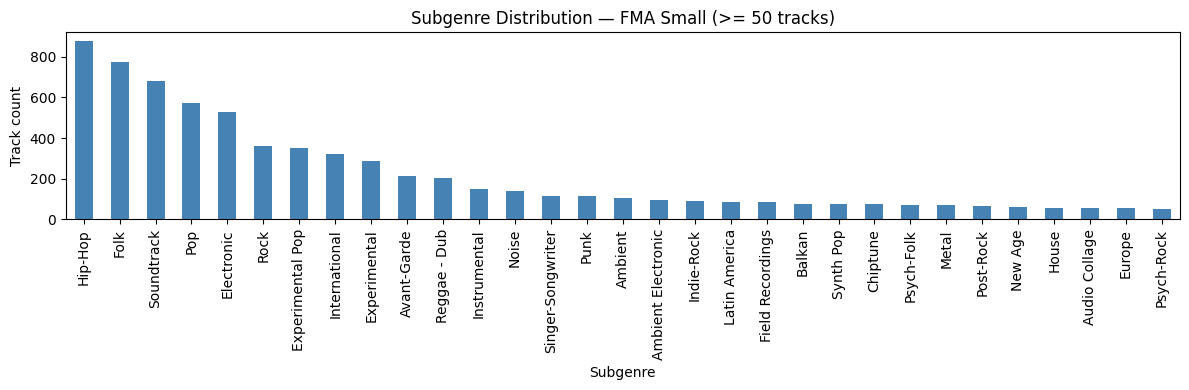

Subgenres: 31
Imbalance ratio (max/min class): 17.5
-> macro F1 is essential; accuracy would be misleading.


In [39]:
counts = y_raw.value_counts()
imbalance = counts.max() / counts.min()

fig, ax = plt.subplots(figsize=(12, 4))
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Subgenre Distribution — FMA {SUBSET.capitalize()} "
             f"(>= {MIN_GENRE_TRACKS} tracks)")
ax.set_xlabel("Subgenre"); ax.set_ylabel("Track count")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_subgenre_distribution.png"), dpi=150)
plt.show()

print(f"Subgenres: {y_raw.nunique()}")
print(f"Imbalance ratio (max/min class): {imbalance:.1f}")
print("-> macro F1 is essential; accuracy would be misleading.")

### Section 3.1 Result

The bar chart confirms the expected skew. Folk, Hip-Hop, Electronic... are the dominant subgenres, each with well over 10× the tracks of the smallest surviving classes. The imbalance ratio printed above captures the full spread between the largest and smallest class.

This distribution is not a problem to fix, it reflects the real composition of the FMA catalogue. But it does mean that any model trained on this data will be pulled toward the large classes by default, which is exactly what macro F1 is designed to counteract. The rest of the project uses macro F1 as the primary metric for this reason.

### 3.2 Missing values and outliers

Audio features can contain genuine extreme values; a very high-pitched track legitimately has an extreme spectral centroid, and a near-silent track legitimately has near zero RMS energy. These are real observations, not errors, so clipping or removing them would discard valid information.

This rules out two common scaling approaches:

- **MinMaxScaler** compresses all values into [0, 1] based on the observed min and max. A single extreme value shifts the entire scale, squashing every other feature into a narrow band.
- **StandardScaler** centres on the mean and scales by standard deviation. Both statistics are sensitive to outliers, so a handful of extreme tracks would distort the scaling for all others.

**RobustScaler** *(chosen)*, centres on the median and scales by the interquartile range (IQR). Both are resistant to extreme values by definition, so the scaling is determined by the bulk of the data and outliers are handled naturally without being removed. This is applied in §5.

In [40]:
n_missing = X_raw.isnull().sum().sum()
print(f"Missing values in feature matrix: {n_missing}")

z = np.abs(scipy_stats.zscore(X_raw.fillna(0)))
print(f"Fraction of values beyond 3 sigma: {(z > 3).mean().mean():.2%}")
print("-> retained, handled via RobustScaler (median / IQR).")

feature_groups = X_raw.columns.str.split("_").str[0].value_counts()
print("\nFeature groups:")
print(feature_groups.to_string())

Missing values in feature matrix: 0
Fraction of values beyond 3 sigma: 0.93%
-> retained, handled via RobustScaler (median / IQR).

Feature groups:
chroma      252
mfcc        140
spectral     70
tonnetz      42
rmse          7
zcr           7


### Section 3.2 Result
**Missing values:** zero explicit NaNs in the feature matrix. FMA's precomputed features are complete for every track in the subset, so no imputation is needed at this stage.

**Outliers:** 0.93% of all feature values fall beyond 3 standard deviations. This is a small but non-trivial fraction, across 518 features and ~6,800 tracks, it represents thousands of individual values. Crucially, these are acoustically meaningful extremes (very percussive tracks, near-silence, unusual tonal content), not data errors. Removing them would silently discard real musical information. RobustScaler, confirmed as the right choice here, will handle these naturally in §5 without any preprocessing needed now."

### 3.3 MFCC correlation structure

MFCCs (Mel-Frequency Cepstral Coefficients) describe the shape of the short-term power spectrum of a track, they are the most common acoustic representation used for genre classification. However, adjacent MFCC coefficients capture overlapping information about the same spectral region, making them inherently correlated with each other.

This correlation is a specific problem for distance-based methods. When features are correlated, the same underlying information is counted multiple times in distance calculations, inflating its contribution to the distance metric. For KNN and the neighbourhood purity analysis, this means the distance between two tracks is distorted by redundant MFCC dimensions rather than reflecting genuine acoustic difference.

PCA addresses this directly: it rotates the feature space so each principal component is orthogonal (uncorrelated) to all others, then compresses the 518 features into a smaller set of components that retain most of the variance. The correlation heatmap below provides the visual justification for this step; if the MFCCs were independent, no preprocessing would be needed."

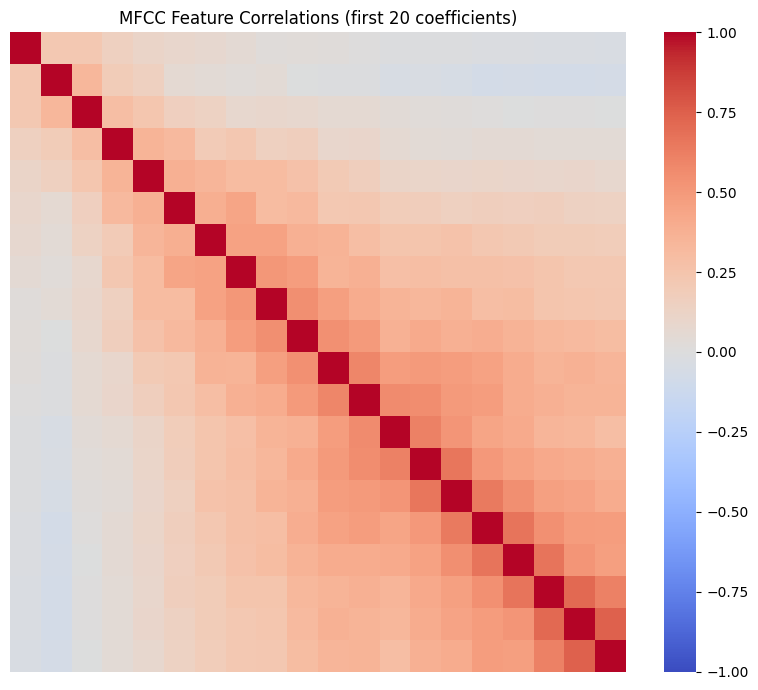

Gradient fading from the diagonal = redundancy -> motivates PCA.


In [41]:
mfcc_cols = [c for c in X_raw.columns if c.startswith("mfcc")][:20]
if mfcc_cols:
    corr = X_raw[mfcc_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title("MFCC Feature Correlations (first 20 coefficients)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "02_mfcc_correlation.png"), dpi=150)
    plt.show()
print("Gradient fading from the diagonal = redundancy -> motivates PCA.")

### Section 3.3 Result

The heatmap shows a clear gradient fading outward from the diagonal. Coefficients that are close to each other (e.g. MFCC-1 and MFCC-2) are strongly correlated, while those further apart gradually become less so. This banded pattern is the visual signature of redundancy:the same spectral information is being captured repeatedly across multiple adjacent coefficients.

PCA is the appropriate response: by rotating the feature space into uncorrelated principal components, it removes this redundancy before any distance is computed. The 100 components chosen in the configuration retain 99.99% of the variance, meaning the compression is essentially lossless while eliminating the correlation problem entirely.

## 4. Label Encoding and Data Partitioning

### Leakage discipline
The order of operations matters. We split **first**, then fit every transformer (scaler, PCA) on the training partition only. `LabelEncoder` is the exception: it is fit on all labels because it only maps fixed genre name strings to integers; it learns nothing from the feature values, so fitting it on the full dataset introduces no leakage.

### Split rationale
We use a stratified **70 / 15 / 15** train / validation / test split. The alternative is an 80 / 10 / 10 split — would leave only ~500 tracks in each evaluation set. With 31 subgenres and class imbalance, several minority classes would end up with fewer than 10 samples in validation and test, making per-class metrics unstable and unreliable. The 15 / 15 split gives ~1,000 tracks per evaluation set, enough to produce stable metrics even for the smallest subgenres. Stratification ensures every subgenre appears proportionally across all three partitions. The test set is sealed until the very end and used exactly once.

### NaN handling
Any residual NaNs are filled with the column median computed before splitting. This is a deliberate exception to the fit-on-train-only rule: as confirmed in the EDA, there are zero NaNs in this dataset. The median fill is a safety net for tracks where a feature genuinely could not be computed (e.g. near-silent audio), which is a structural property of the track itself rather than a statistic learned from the training distribution. In practice this step does nothing here, but it is documented explicitly so the decision is transparent.

In [42]:
le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
genre_names = le.classes_
n_classes   = len(genre_names)

X = X_raw.values.astype(np.float32)
col_medians = np.nanmedian(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_enc, test_size=0.15, random_state=SEED, stratify=y_enc)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176,
    random_state=SEED, stratify=y_trainval)

feature_names = X_raw.columns.tolist()
print(f"Classes: {n_classes}")
print(f"Train {len(X_train):,} | Val {len(X_val):,} | Test {len(X_test):,}")

Classes: 31
Train 4,808 | Val 1,028 | Test 1,030


## 5. Preprocessing: RobustScaler + PCA

Two transforms are applied in sequence, both fitted on the training partition only and then applied to validation and test without refitting. This is the core leakage guard, if the scaler or PCA were fitted on the full dataset, information from the evaluation sets would leak into the training representation.

**RobustScaler** centres each feature on its median and scales by its IQR. As established in the EDA, the feature matrix contains genuine outliers that would distort a mean- or range-based scaler. RobustScaler handles these without removing them.

**PCA** then rotates the scaled features into uncorrelated principal components and reduces dimensionality from 518 to 100. As shown by the MFCC correlation heatmap, the raw features are highly redundant; PCA removes that redundancy before any distance based computation takes place.

**Why separate standalone projections and pipeline-internal ones:** the supervised models (Logistic Regression, KNN, MLP) each contain their own scaler and PCA as pipeline steps, which means they refit both transforms inside every cross-validation fold preventing any leakage during model evaluation. The standalone projections computed here are used only by the neighbourhood purity analysis and KMeans clustering, which operate outside a CV loop and need a single fixed representation of the data.

In [43]:
CKPT_PRE = os.path.join(CKPT_DIR, f"preprocess_{SUBSET}.pkl")

if os.path.exists(CKPT_PRE):
    (scaler, pca, X_train_pca, X_val_pca,
     X_test_pca, X_trainval_pca) = joblib.load(CKPT_PRE)
else:
    scaler = RobustScaler()
    X_train_s    = scaler.fit_transform(X_train)
    X_val_s      = scaler.transform(X_val)
    X_test_s     = scaler.transform(X_test)
    X_trainval_s = scaler.transform(X_trainval)

    pca = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
    X_train_pca    = pca.fit_transform(X_train_s)
    X_val_pca      = pca.transform(X_val_s)
    X_test_pca     = pca.transform(X_test_s)
    X_trainval_pca = pca.transform(X_trainval_s)

    joblib.dump((scaler, pca, X_train_pca, X_val_pca,
                 X_test_pca, X_trainval_pca), CKPT_PRE)

print(f"Variance retained by {N_PCA_COMPONENTS} PCs: "
      f"{pca.explained_variance_ratio_.sum():.2%}")

Variance retained by 100 PCs: 99.99%


### 5.1 2D projection coloured by subgenre

A first visual answer to the research question. We project the training set onto the top two principal components and colour each point by its official subgenre label.

If subgenres are acoustically coherent, we would expect at least partial separation (clusters of the same colour grouping together). Heavy overlap across colours is itself a finding: it means the official labels do not correspond to distinct regions in acoustic space, at least along the two most prominent axes of variation.

One important caveat: PC1 and PC2 together capture only a fraction of the total variance. Overlap in this 2D view does not rule out separation in the full 100-component space; it is an early indicator, not a definitive test. The supervised models and neighbourhood analysis in later sections evaluate the full representation.

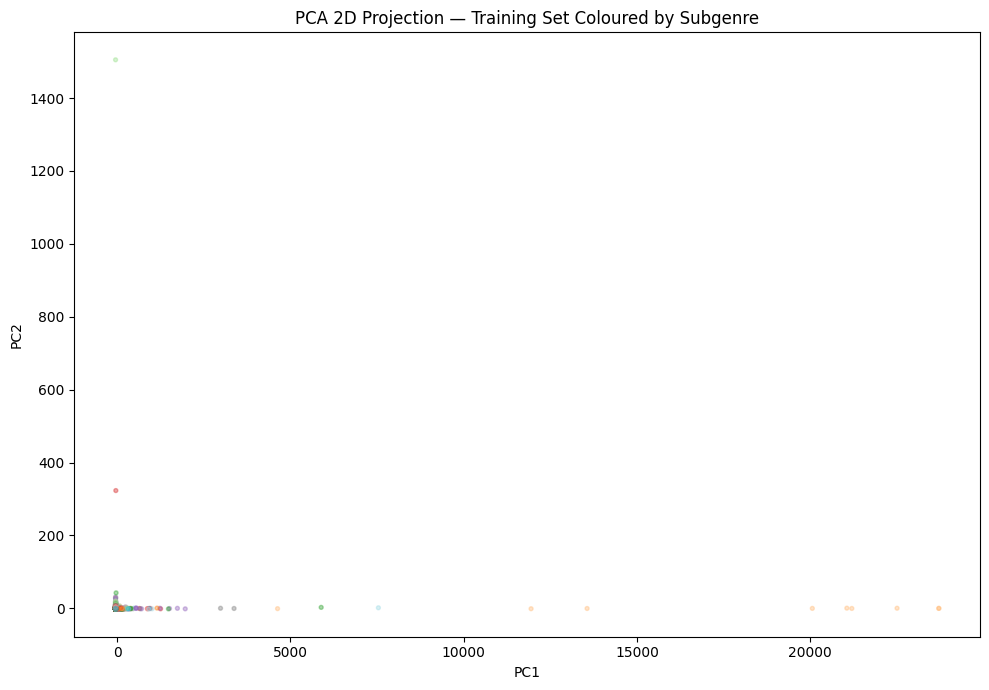

In [44]:
pca2  = PCA(n_components=2, random_state=SEED)
X_2d  = pca2.fit_transform(scaler.transform(X_train))

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train,
                cmap="tab20", alpha=0.4, s=8)
ax.set_title("PCA 2D Projection — Training Set Coloured by Subgenre")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_pca_2d_subgenres.png"), dpi=150)
plt.show()

### Section 5.1 Result

The scatter plot shows substantial overlap across subgenre colours throughout the PCA space. There is no clean partitioning of the 2D projection into colour-separated regions: tracks from very different official subgenres occupy the same areas of the plot.

This is an early visual signal consistent with the project's central claim: the official FMA subgenre taxonomy does not correspond cleanly to distinct acoustic regions. However, as noted above, this view is limited to two dimensions. The supervised evaluation across all 100 components will give a more complete and quantitative picture of how much acoustic separation actually exists.

## 6. Supervised Models — Used as a Measurement Device

We are **not** optimising for the best classifier. These models answer one question: *how predictable are the official subgenre labels from acoustic features?* A ceiling well below perfect is a finding — it quantifies how acoustically incoherent the taxonomy is. Each model is wrapped in a `Pipeline` so preprocessing is refitted inside every CV fold (no leakage) and the whole object is serialisable.

| Model | Role |
|---|---|
| Majority dummy | Absolute floor — any signal must beat this |
| Logistic Regression | Linear reference — how much signal is linearly accessible |
| K-Nearest Neighbours | **Dual role**: classifier *and* the engine of the neighbourhood audit. A KNN error is a track whose acoustic neighbourhood disagrees with its official label |
| Random Forest | Non-linear ceiling; deliberately omits PCA — see below |
| Gradient Boosting | Second non-linear model — see below |
| MLP | Higher-capacity neural reference |

**KNN — why cosine distance:** audio features like MFCCs represent spectral shape. Two tracks can have the same tonal character at different overall volumes, producing feature vectors that point in the same direction but differ in magnitude. Cosine distance measures the angle between vectors and ignores magnitude, making it more appropriate here than Euclidean distance which would treat loudness differences as genuine acoustic dissimilarity.

**Random Forest — why no PCA:** trees split on individual features and are not affected by inter-feature correlation the way distance-based models are. More importantly, omitting PCA means the Random Forest operates in the original 518-feature space — this is required for SHAP's TreeExplainer to produce attributions in terms of the actual named audio features (e.g. `mfcc_mean_01`) rather than abstract principal components that have no intuitive interpretation.

**Gradient Boosting and MLP — why two non-linear models:** a single non-linear result could be a modelling artefact. Including both Gradient Boosting (an ensemble of shallow trees trained sequentially) and MLP (a neural network) provides a robustness check — if both reach a similar ceiling independently, the finding is more credible than if only one model produced it.

In [45]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)

lr_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    LogisticRegression(max_iter=2000, random_state=SEED))])

knn_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    KNeighborsClassifier(n_neighbors=K_NEIGHBOURS,
                                    metric="cosine", weights="distance"))])

rf_pipe = Pipeline([                       # NO pca: trees + SHAP need raw space
    ("scaler", RobustScaler()),
    ("clf",    RandomForestClassifier(n_estimators=200, random_state=SEED,
                                      n_jobs=-1))])

gb_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf",    HistGradientBoostingClassifier(max_iter=200, random_state=SEED))])

mlp_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400,
                             early_stopping=True, random_state=SEED))])

models = {"Dummy": dummy, "Logistic Regression": lr_pipe, "KNN": knn_pipe,
          "Random Forest": rf_pipe, "Gradient Boosting": gb_pipe, "MLP": mlp_pipe}
print("Pipelines built:", list(models))

Pipelines built: ['Dummy', 'Logistic Regression', 'KNN', 'Random Forest', 'Gradient Boosting', 'MLP']


### 6.1 Cross-validation

5-fold stratified cross-validation is run on the combined train + validation partition. We report both the mean macro F1 and its standard deviation across folds — a high standard deviation signals an unstable model whose ranking we should not over-interpret, even if its mean score looks competitive.

This is part of evaluating rigorously: a single number without its spread is not a result. If two models are within one standard deviation of each other, their ranking is not meaningful.

In [46]:
CKPT_CV = os.path.join(CKPT_DIR, f"cv_{SUBSET}.pkl")

if os.path.exists(CKPT_CV):
    cv_results = joblib.load(CKPT_CV)
else:
    cv_results = {}
    for name, model in models.items():
        s = cross_val_score(model, X_trainval, y_trainval,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
        cv_results[name] = {"mean": s.mean(), "std": s.std()}
        print(f"{name:<22} F1 = {s.mean():.3f} +/- {s.std():.3f}")
    joblib.dump(cv_results, CKPT_CV)

pd.DataFrame(cv_results).T

Dummy                  F1 = 0.007 +/- 0.000
Logistic Regression    F1 = 0.275 +/- 0.024
KNN                    F1 = 0.213 +/- 0.015
Random Forest          F1 = 0.237 +/- 0.020
Gradient Boosting      F1 = 0.324 +/- 0.023
MLP                    F1 = 0.237 +/- 0.036


,mean,std
Dummy,0.007304,0.000002
Logistic Regression,0.275164,0.023547
KNN,0.213027,0.015432
Random Forest,0.236863,0.020280
Gradient Boosting,0.323506,0.022983
MLP,0.237284,0.035880


## 7. Hyperparameter Tuning

- **Random Forest → `RandomizedSearchCV`**: the parameter space (number of trees, max depth, features per split, minimum samples per leaf) is large and combinatorial; exhaustive search would be prohibitively slow. Random sampling explores it efficiently within a fixed budget (`N_ITER_RANDOM` iterations).
- **KNN → `GridSearchCV`**: the space is small and discrete (number of neighbours, distance metric, weighting scheme), so exhaustive search is feasible and preferable — it guarantees finding the best combination within the grid.
- **RandomizedSearchCV → Gradient Boosting.** `HistGradientBoostingClassifier` is histogram-based and substantially faster to train than a standard GB implementation, making a randomised search tractable even on larger subsets. We tune learning rate, tree depth, number of iterations and regularisation strength. Including a tuned GB makes the comparison symmetric: all three non-linear models (RF, GB, MLP) are given equivalent opportunity to find their best configuration, rather than comparing tuned RF and KNN against a default GB.

All three searches are run on the combined train+val set with the same stratified cross-validation object used throughout. The test set is never involved in tuning. Results are checkpointed so an interrupted run resumes without restarting.

In [50]:
from sklearn.ensemble import HistGradientBoostingClassifier

CKPT_TUNE = os.path.join(CKPT_DIR, f"tune_{SUBSET}.pkl")

if os.path.exists(CKPT_TUNE):
    rf_search, knn_search = joblib.load(CKPT_TUNE)
else:
    rf_dist = {
        "clf__n_estimators":      [100, 200,], # change to max 200 if you get stuck on a tree for a prolonged period of time
        "clf__max_depth":         [None, 10, 20, 30], # can be lowered to max 20
        "clf__min_samples_split": [2, 5, 10],
        "clf__max_features":      ["sqrt", "log2", 0.3],
        "clf__min_samples_leaf":  [1, 2, 4]}
    rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=10,
                                   cv=cv, scoring="f1_macro", n_jobs=-1,
                                   random_state=SEED, verbose=1)
    rf_search.fit(X_trainval, y_trainval)
    print("Best RF :", rf_search.best_params_, rf_search.best_score_)

    knn_grid = {
        "clf__n_neighbors": [5, 10, 15, 20, 30],
        "clf__metric":      ["cosine", "euclidean", "manhattan"],
        "clf__weights":     ["uniform", "distance"]}
    knn_search = GridSearchCV(knn_pipe, knn_grid, cv=cv,
                              scoring="f1_macro", n_jobs=-1, verbose=1)
    knn_search.fit(X_trainval, y_trainval)
    print("Best KNN:", knn_search.best_params_, knn_search.best_score_)

    gb_dist = {
        "clf__max_iter":          [100, 200, 300],
        "clf__learning_rate":     [0.05, 0.1, 0.2],
        "clf__max_depth":         [None, 6, 12],
        "clf__max_leaf_nodes":    [31, 63],
        "clf__l2_regularization": [0.0, 1.0]}
    gb_search = RandomizedSearchCV(gb_pipe, gb_dist, n_iter=10,
                                   cv=cv, scoring="f1_macro", n_jobs=-1,
                                   random_state=SEED, verbose=1)
    gb_search.fit(X_trainval, y_trainval)
    print("Best GB :", gb_search.best_params_, gb_search.best_score_)

    joblib.dump((rf_search, knn_search), CKPT_TUNE)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best RF : {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_features': 0.3, 'clf__max_depth': 30} 0.24703509949854804
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best KNN: {'clf__metric': 'cosine', 'clf__n_neighbors': 5, 'clf__weights': 'distance'} 0.2517758370760646
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best GB : {'clf__max_leaf_nodes': 63, 'clf__max_iter': 300, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__l2_regularization': 1.0} 0.32994131137339794


In [51]:
joblib.dump((rf_search, knn_search, gb_search), CKPT_TUNE)
print("re-saved with gb_search")

re-saved with gb_search


## 8. Supervised Evaluation

All models are fitted on the training partition and evaluated on the validation set. The tuned RF and KNN replace their untuned counterparts. Three metrics are reported for each model:

- **Macro F1** — primary metric; every subgenre weighted equally regardless of size
- **Weighted F1** — included for reference; the gap between this and macro F1 shows how much the model leans on large classes
- **ROC-AUC (one-vs-rest)** — ranking quality; tells us whether the model can distinguish subgenres even when it cannot cleanly classify them

The best model is then evaluated on the validation confusion matrix and per-class classification report. The confusion matrix shows *which* subgenres are being mixed up — this is directly relevant to the audit, since systematic confusion between two subgenres is evidence that the taxonomy over-fragments a single acoustic style.

**Interpretation focus:** the *absolute level* of the best score is the finding, not whether it beats some benchmark. A macro F1 ceiling in the low-to-mid 0.3s across 31 subgenres — with strong models, proper tuning, and no leakage — means the labels themselves are only weakly determined by how the music sounds. That is the quantitative core of the audit claim.

In [52]:
CKPT_FIT = os.path.join(CKPT_DIR, f"fit_{SUBSET}.pkl")

if os.path.exists(CKPT_FIT):
    fitted = joblib.load(CKPT_FIT)
else:
    fitted = {}
    to_fit = {"Dummy": dummy,
              "Logistic Regression": lr_pipe,
              "KNN (tuned)": knn_search.best_estimator_,
              "Random Forest (tuned)": rf_search.best_estimator_,
              "Gradient Boosting": gb_search.best_estimator_,
              "MLP": mlp_pipe}
    for name, m in to_fit.items():
        m.fit(X_train, y_train)
        fitted[name] = m
    joblib.dump(fitted, CKPT_FIT)

rows = []
for name, m in fitted.items():
    yp = m.predict(X_val)
    try:
        roc = roc_auc_score(y_val, m.predict_proba(X_val),
                            multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    rows.append({"Model": name,
                 "Val F1 macro": round(f1_score(y_val, yp, average="macro"), 4),
                 "Val F1 weighted": round(f1_score(y_val, yp, average="weighted"), 4),
                 "Val ROC-AUC": round(roc, 4)})

results_df = pd.DataFrame(rows).sort_values("Val F1 macro", ascending=False)
results_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"), index=False)
results_df

,Model,Val F1 macro,Val F1 weighted,Val ROC-AUC
4,Gradient Boosting,0.3283,0.4314,0.8876
5,MLP,0.2839,0.3877,0.8396
1,Logistic Regression,0.2837,0.3834,0.8467
2,KNN (tuned),0.2714,0.3467,0.7033
3,Random Forest (tuned),0.2351,0.3686,0.8478
0,Dummy,0.0073,0.0288,0.5000


Selected best supervised model: Gradient Boosting


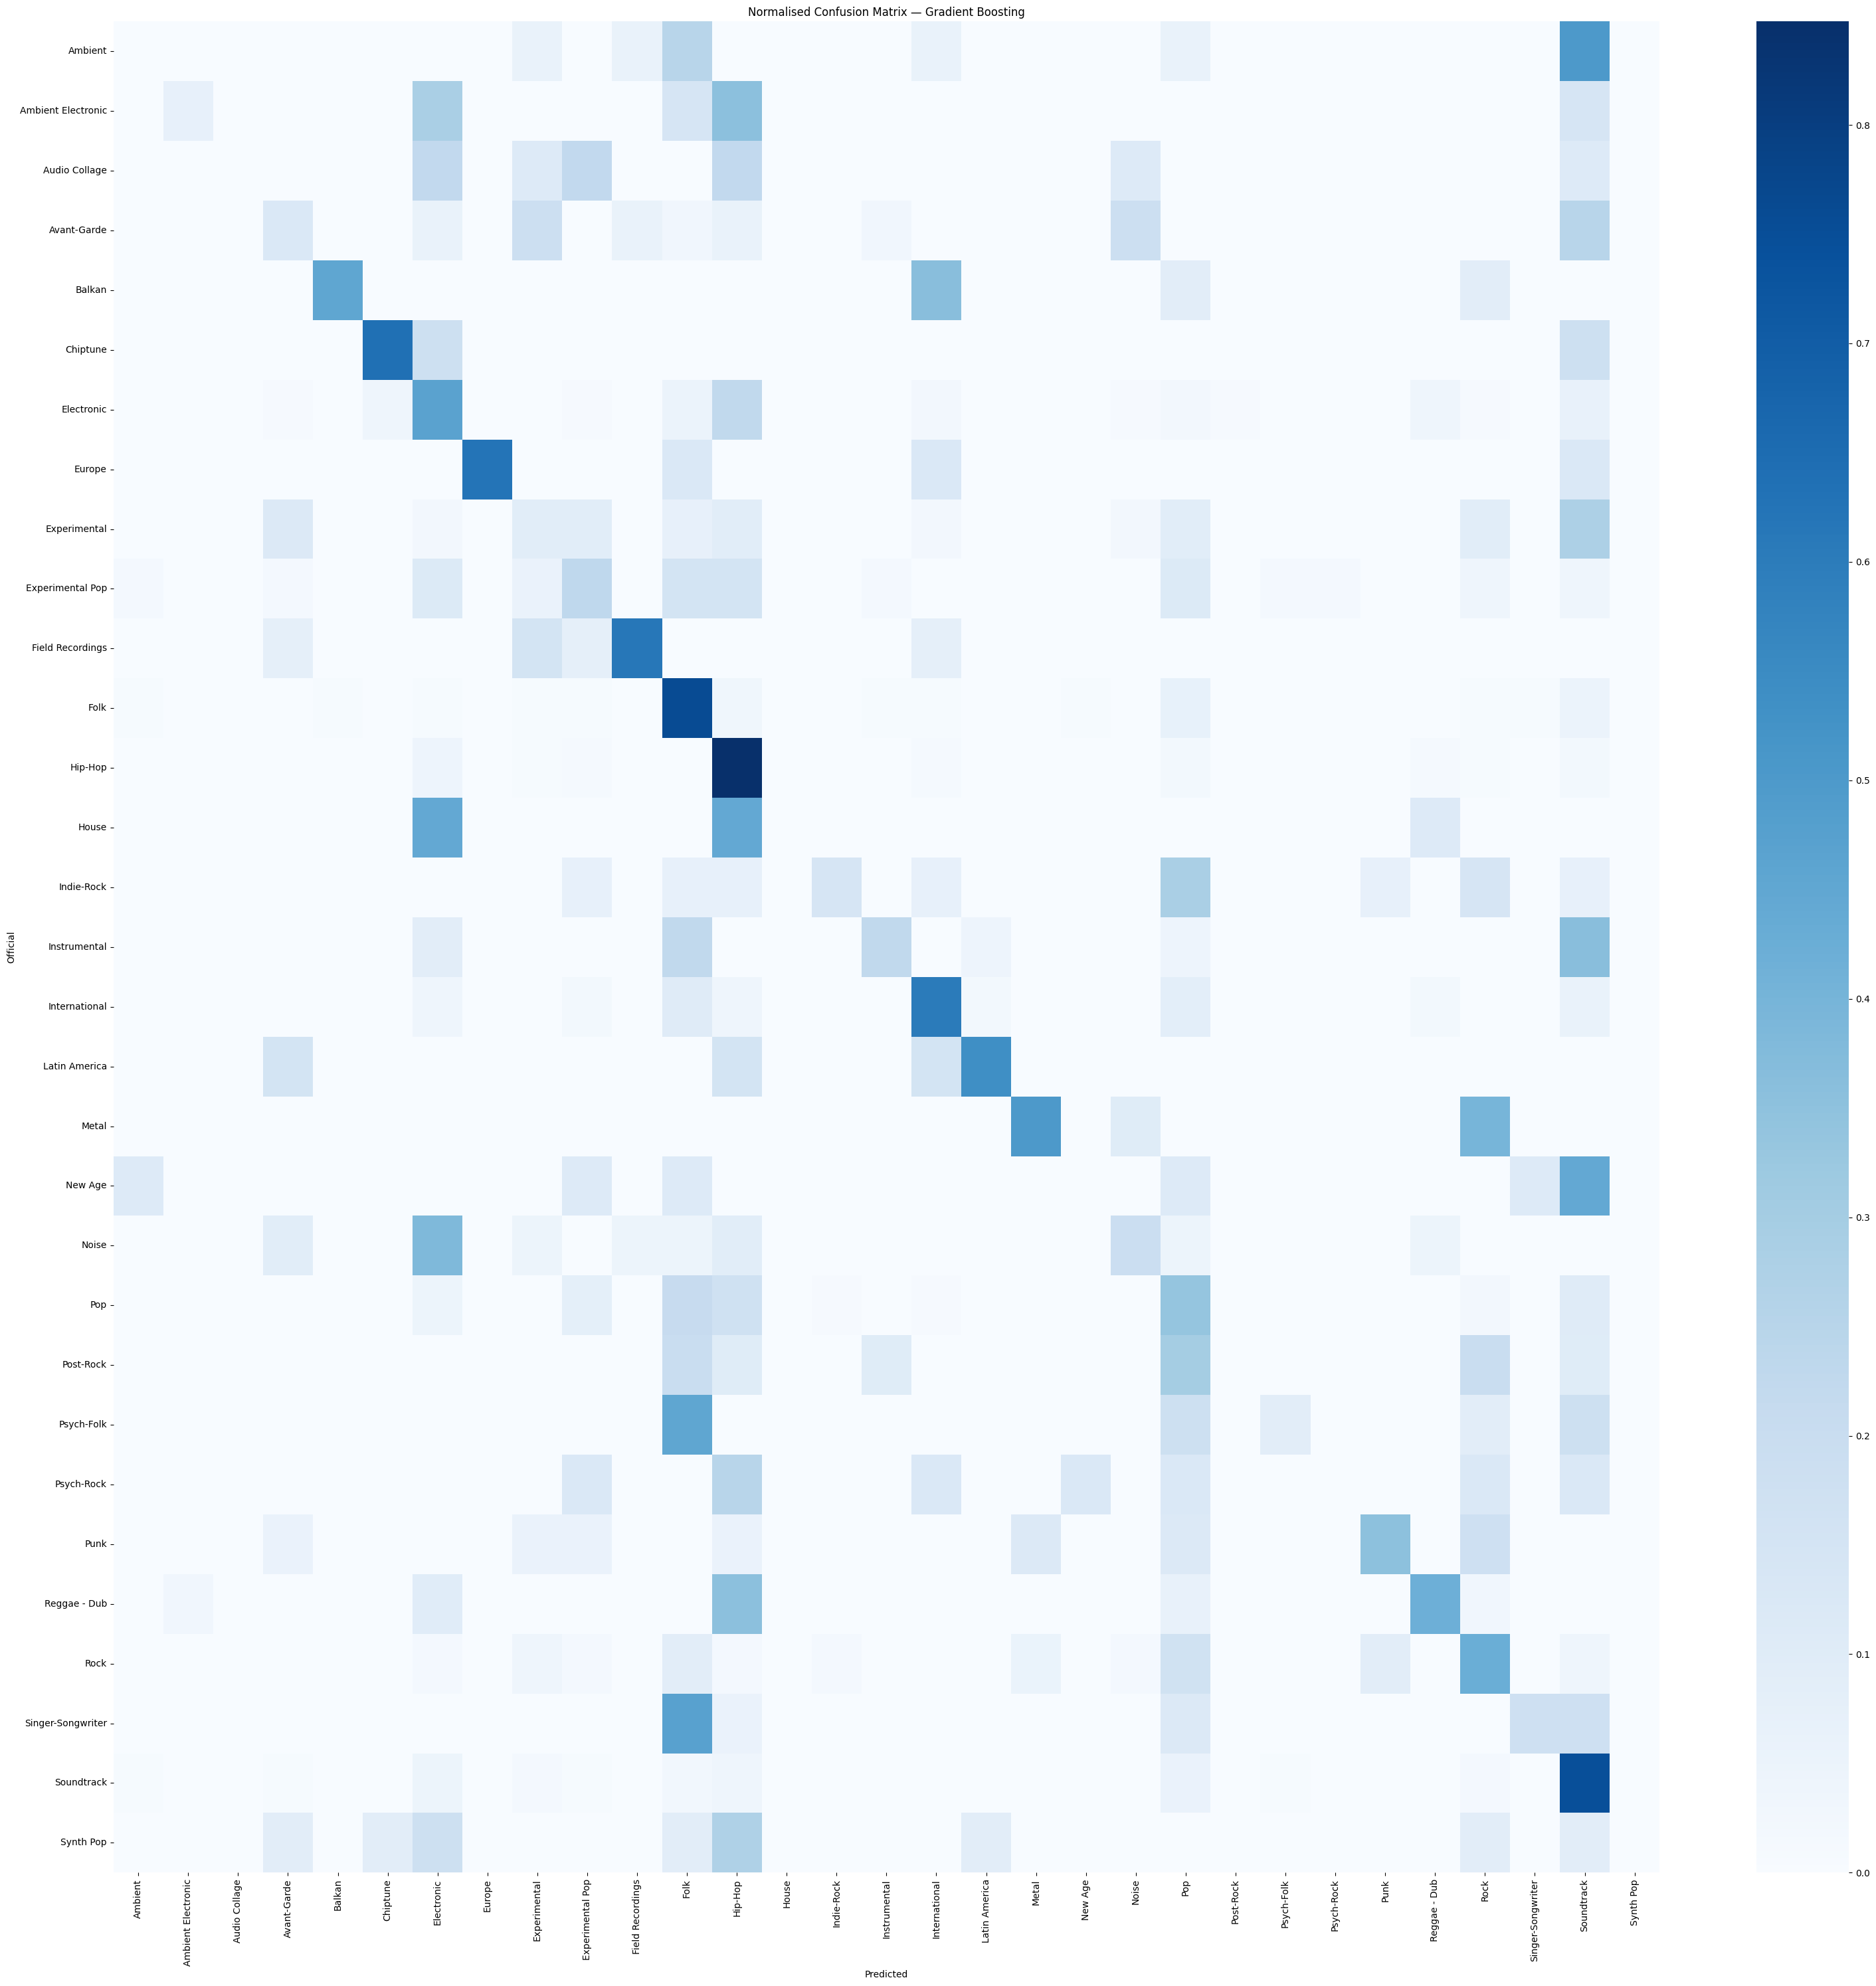

                    precision    recall  f1-score   support

           Ambient       0.00      0.00      0.00        16
Ambient Electronic       0.50      0.07      0.12        14
     Audio Collage       0.00      0.00      0.00         9
       Avant-Garde       0.21      0.12      0.16        32
            Balkan       0.83      0.45      0.59        11
          Chiptune       0.64      0.64      0.64        11
        Electronic       0.40      0.47      0.43        79
            Europe       1.00      0.62      0.77         8
      Experimental       0.16      0.09      0.12        43
  Experimental Pop       0.32      0.23      0.27        52
  Field Recordings       0.67      0.62      0.64        13
              Folk       0.53      0.76      0.62       116
           Hip-Hop       0.54      0.85      0.66       131
             House       0.00      0.00      0.00         9
        Indie-Rock       0.50      0.14      0.22        14
      Instrumental       0.56      0.23

In [53]:
non_dummy       = results_df[results_df.Model != "Dummy"]
best_model_name = non_dummy.iloc[0]["Model"]
best_model      = fitted[best_model_name]
print("Selected best supervised model:", best_model_name)

yp = best_model.predict(X_val)
cm = confusion_matrix(y_val, yp)
cm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, n_classes), max(6, n_classes-1)))
sns.heatmap(cm, xticklabels=genre_names, yticklabels=genre_names,
            cmap="Blues", ax=ax)
ax.set_title(f"Normalised Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Official")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_confusion_best.png"), dpi=150)
plt.show()

print(classification_report(y_val, yp, target_names=genre_names))

## 9. Neighbourhood Analysis

This is the explicit, standalone version of what KNN does implicitly. We build a `NearestNeighbors` index on the training set (PCA space, cosine distance) and for every validation track ask:

- **Neighbourhood purity** — what fraction of its k nearest neighbours share its official label? Low purity for a subgenre means that label does not correspond to a coherent acoustic region.
- **Neighbour vote** — what label does the neighbourhood majority suggest? Disagreement with the official label flags a relabelling candidate.

Separating retrieval (the index) from the decision (the vote) lets us vary k independently of the tuned KNN classifier. This is intentional: the tuned classifier uses k=5 (tight neighbourhoods, optimised for classification accuracy), while this analysis uses k=20 (a wider neighbourhood that gives a more stable estimate of local label purity). A subgenre with low purity at k=20 is a strong signal — it means even looking at 20 nearby tracks, the official label still does not dominate.

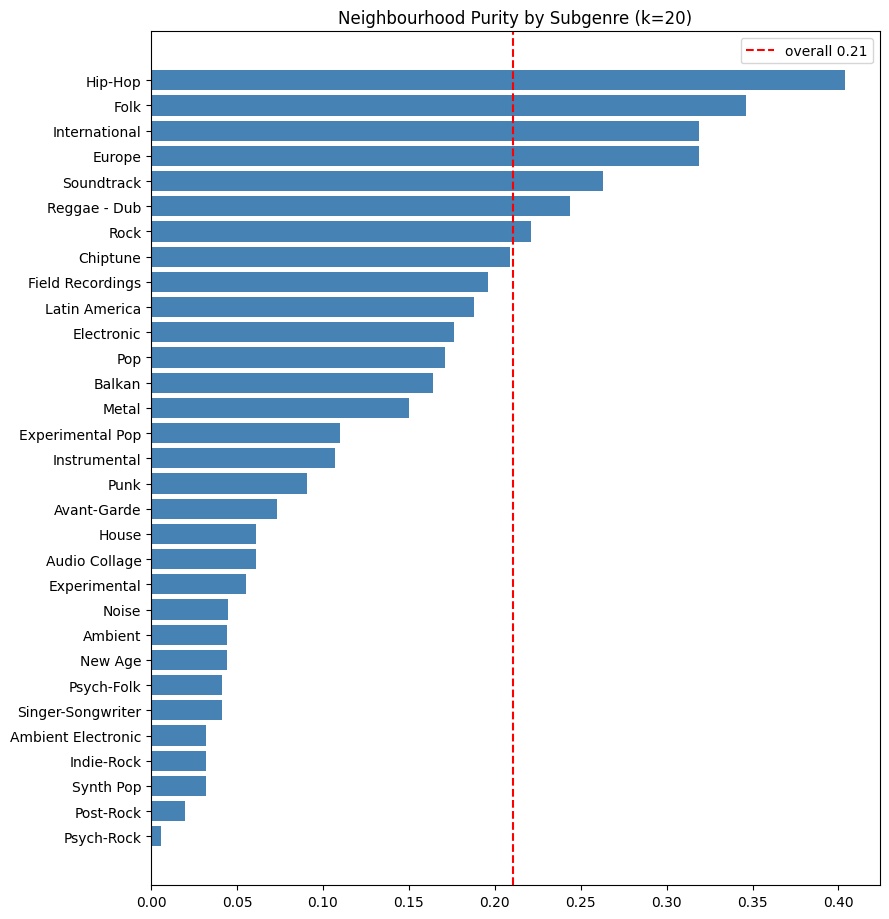

Overall purity: 0.211
Neighbour vote agreement with official: 37.35%


In [54]:
CKPT_NN = os.path.join(CKPT_DIR, f"nn_{SUBSET}.pkl")

if os.path.exists(CKPT_NN):
    purity_scores, voted_labels, nn_idx = joblib.load(CKPT_NN)
else:
    index = NearestNeighbors(n_neighbors=K_NEIGHBOURS, metric="cosine",
                             algorithm="brute", n_jobs=-1)
    index.fit(X_train_pca)
    _, nn_idx = index.kneighbors(X_val_pca)

    purity_scores = np.array([
        (y_train[row] == lbl).mean()
        for row, lbl in zip(nn_idx, y_val)])
    voted_labels = np.array([
        scipy_stats.mode(y_train[row], keepdims=True).mode[0]
        for row in nn_idx])

    joblib.dump((purity_scores, voted_labels, nn_idx), CKPT_NN)

rows = []
for g, name in enumerate(genre_names):
    m = y_val == g
    if m.sum():
        rows.append({"Subgenre": name,
                     "Mean purity": round(purity_scores[m].mean(), 3),
                     "N": int(m.sum())})
purity_df = pd.DataFrame(rows).sort_values("Mean purity", ascending=False)
purity_df.to_csv(os.path.join(RESULTS_DIR, "neighbourhood_purity.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, max(5, n_classes*0.3)))
ps = purity_df.sort_values("Mean purity")
ax.barh(ps["Subgenre"], ps["Mean purity"], color="steelblue")
ax.axvline(purity_scores.mean(), color="red", ls="--",
           label=f"overall {purity_scores.mean():.2f}")
ax.set_title(f"Neighbourhood Purity by Subgenre (k={K_NEIGHBOURS})")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_neighbourhood_purity.png"), dpi=150)
plt.show()

print(f"Overall purity: {purity_scores.mean():.3f}")
print(f"Neighbour vote agreement with official: "
      f"{(voted_labels == y_val).mean():.2%}")

### Section 9 — Result

**Overall purity and neighbour vote agreement** are printed above. These two numbers together tell us how much the local acoustic structure agrees with the official labels: purity measures it per-track and neighbourhood vote agreement measures it as a classification decision.

The subgenres at the bottom of the chart are the primary audit red flags. They are the strongest candidates for relabelling or taxonomy restructuring: tracks officially labelled with these subgenres are, by acoustic evidence, more similar to tracks in other categories than to their supposed peers. These patterns carry forward directly into the three-way comparison of official labels, classifier predictions, and neighbourhood votes.

## 10. Unsupervised Clustering — The Core Contribution

This is the heart of the project. We discard the official labels entirely and ask: **what groupings does the acoustic data actually support?**

We cluster the PCA-reduced features with KMeans. The number of clusters is **chosen by the data**, not set to match the official subgenre count — we sweep `CLUSTER_RANGE` and pick the k with the best silhouette score. Forcing the cluster count to equal the number of official subgenres would bias the comparison toward agreement and undermine the whole argument.

**Why KMeans:** KMeans is interpretable, scalable, and produces hard cluster assignments that map cleanly onto the three-way comparison with official labels and classifier predictions. The main alternative considered was HDBSCAN, a density-based method that can find clusters of arbitrary shape and does not require specifying k in advance. HDBSCAN was not chosen because it also marks many points as noise (unclustered), which complicates the comparison — every validation track needs a cluster assignment for the three-way analysis to work. KMeans guarantees this. The assumption that clusters are roughly convex and similarly sized in PCA space is reasonable given that PCA produces a well-conditioned, variance-normalised representation.

**On metric choice (why silhouette with cosine distance is valid here):** cluster quality is evaluated with cosine distance, the same metric used by the KNN classifier and the neighbourhood purity analysis, so the geometry is consistent across every unsupervised component — the clusters are judged in the exact space the rest of the audit operates in.

### 10.1 Choosing the number of clusters — silhouette vs AMI

We select the number of clusters by **silhouette score**, a purely label-free measure of how cohesive and well-separated the clusters are. This is the principled choice: the data, not the official taxonomy, decides the grouping granularity.

But we also compute a second curve on the same range — the **Adjusted Mutual Information (AMI)** between each candidate clustering and the official subgenre labels. Plotting these together is itself a result, not just a diagnostic:

- The **silhouette peak** tells us the number of clusters the acoustic data *naturally* wants.
- The **AMI curve** tells us how closely each clustering reproduces the official taxonomy.

The interesting outcome is **divergence**. If silhouette peaks at a k that is very different from the official subgenre count, *and* AMI stays low across the whole range, that is direct evidence that the acoustic structure does not align with the human taxonomy at any granularity — the strongest possible form of our central claim. If instead AMI rises toward the official count, the taxonomy is at least partially acoustically grounded. Either way, the relationship between the two curves is the headline diagnostic.

We pick `best_k` strictly by silhouette (the data-driven criterion) and report where AMI sits at that k, rather than choosing k to maximise agreement — doing the latter would bias the entire analysis toward the conclusion we are testing.

**Dev-run caveat:** on the Small subset the cluster range is 5–40 in steps of 5, which is a narrow search over a limited dataset. The silhouette-optimal k found here should be treated as a methodology demonstration rather than a final result. On the full dataset with the wider range (5–160 in steps of 10), the optimal k and AMI values may shift substantially — those numbers are what belong in the report.

k=5    silhouette=0.8417  AMI=0.0031
k=10   silhouette=0.7657  AMI=0.0057
k=15   silhouette=0.7802  AMI=0.0054
k=20   silhouette=0.1246  AMI=0.1091
k=25   silhouette=0.1830  AMI=0.1019
k=30   silhouette=0.1263  AMI=0.1127
k=35   silhouette=0.0480  AMI=0.1174
k=40   silhouette=0.0217  AMI=0.1169


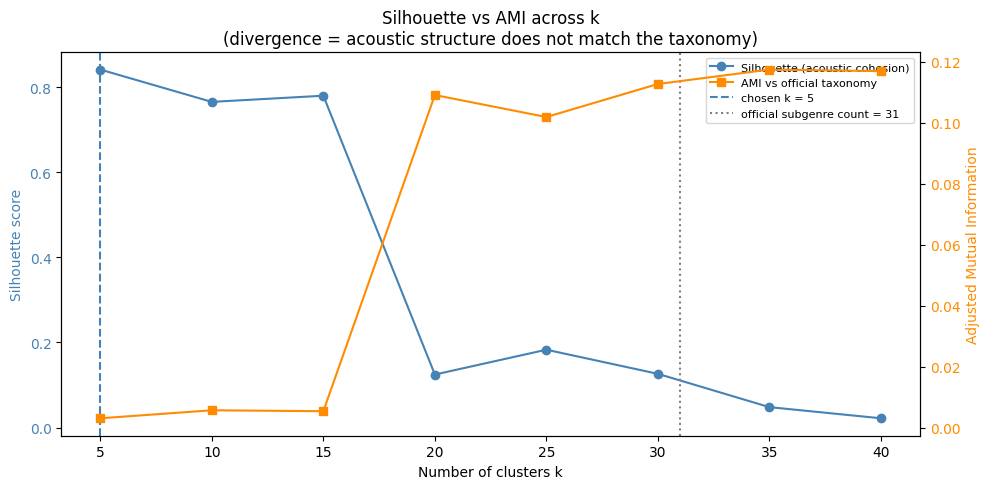

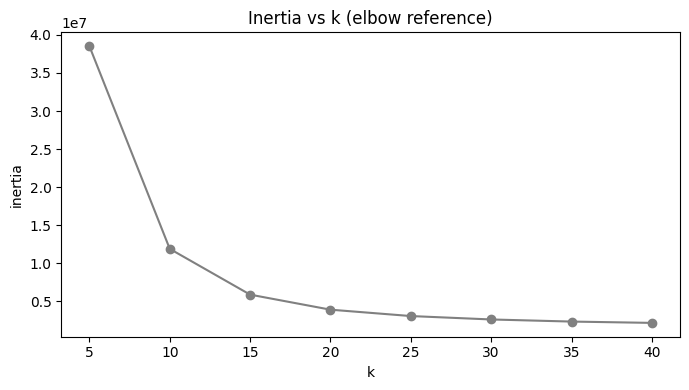


Chosen k             = 5
AMI at that k        = 0.003
Official subgenre count = 31
Max AMI over range   = 0.117 (at k=35)


In [55]:
CKPT_KSEL = os.path.join(CKPT_DIR, f"ksel_{SUBSET}.pkl")

FORCE_K = None   # biased exploration override. Set to None for the principled silhouette choice. 

if FORCE_K is None and os.path.exists(CKPT_KSEL):
    sil_scores, ami_scores, inertias, best_k = joblib.load(CKPT_KSEL)
else:
    sil_scores, ami_scores, inertias = {}, {}, {}
    for k in CLUSTER_RANGE:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lab = km.fit_predict(X_train_pca)
        # DEV sample_size 3000 keeps silhouette fast on Small.
        # FULL: raise to min(20000, len(X_train_pca)) for a more
        # stable estimate on the full dataset (if you have the hardware).
        sil_scores[k] = silhouette_score(
            X_train_pca, lab, metric="cosine",
            sample_size=min(3000, len(X_train_pca)),  # FULL: min(20000, ...)
            random_state=SEED)
        ami_scores[k] = adjusted_mutual_info_score(y_train, lab)
        inertias[k]   = km.inertia_
        print(f"k={k:<4} silhouette={sil_scores[k]:.4f}  "
              f"AMI={ami_scores[k]:.4f}")
    best_k = max(sil_scores, key=sil_scores.get)
    if FORCE_K is not None:
        print(f"\n*** OVERRIDE: silhouette chose k={best_k}, "
              f"forcing k={FORCE_K} for biased exploration ***")
        best_k = FORCE_K
    joblib.dump((sil_scores, ami_scores, inertias, best_k), CKPT_KSEL)

ks       = list(sil_scores)
n_off    = n_classes  # number of official subgenres, for reference line

fig, ax1 = plt.subplots(figsize=(10, 5))

l1, = ax1.plot(ks, [sil_scores[k] for k in ks], "o-",
               color="steelblue", label="Silhouette (acoustic cohesion)")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Silhouette score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.axvline(best_k, color="steelblue", ls="--",
            label=f"chosen k = {best_k}")

ax2 = ax1.twinx()
l2, = ax2.plot(ks, [ami_scores[k] for k in ks], "s-",
               color="darkorange", label="AMI vs official taxonomy")
ax2.set_ylabel("Adjusted Mutual Information", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.axvline(n_off, color="grey", ls=":",
            label=f"official subgenre count = {n_off}")

lines = [l1, l2,
         plt.Line2D([0], [0], color="steelblue", ls="--"),
         plt.Line2D([0], [0], color="grey", ls=":")]
labels = ["Silhouette (acoustic cohesion)",
          "AMI vs official taxonomy",
          f"chosen k = {best_k}",
          f"official subgenre count = {n_off}"]
ax1.legend(lines, labels, loc="upper right", fontsize=8)
ax1.set_title("Silhouette vs AMI across k\n"
              "(divergence = acoustic structure does not match the taxonomy)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_silhouette_vs_ami.png"), dpi=150)
plt.show()

# --- inertia elbow kept as a secondary reference ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, [inertias[k] for k in ks], "o-", color="grey")
ax.set_title("Inertia vs k (elbow reference)")
ax.set_xlabel("k"); ax.set_ylabel("inertia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06b_inertia_elbow.png"), dpi=150)
plt.show()

print(f"\nChosen k             = {best_k}")
print(f"AMI at that k        = {ami_scores[best_k]:.3f}")
print(f"Official subgenre count = {n_off}")
print(f"Max AMI over range   = {max(ami_scores.values()):.3f} "
      f"(at k={max(ami_scores, key=ami_scores.get)})")

### 10.2 Fit the final clustering

KMeans is fitted with the silhouette-optimal k on the training set. Cluster assignments are then predicted for the validation tracks — these cluster IDs become the **data-driven label system**, derived with zero knowledge of the official taxonomy. They are compared against official labels and classifier predictions in the three-way comparison that follows.

In [56]:
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_train = kmeans.fit_predict(X_train_pca)
cluster_val   = kmeans.predict(X_val_pca)
print(f"KMeans fitted with k={best_k}")
print(f"Cluster sizes (val): "
      f"{np.bincount(cluster_val, minlength=best_k).tolist()}")

KMeans fitted with k=5
Cluster sizes (val): [1023, 2, 2, 0, 1]


### 10.3 Do the clusters agree with the official taxonomy?

We compare the data-driven clusters against the official subgenre labels using three agreement metrics, all corrected for chance (so 0 ≈ random agreement, 1 = identical partitions):

- **Adjusted Mutual Information (AMI)** — how much information the two label systems share, corrected for the agreement expected by chance alone. This is the headline metric for the audit.
- **Adjusted Rand Index (ARI)** — pairwise agreement: what fraction of track pairs are in the same cluster under both systems, corrected for chance. Reported alongside AMI as a robustness check — if both tell the same story, the finding is not an artefact of the metric.
- **Normalised Mutual Information (NMI)** — like AMI but not chance-adjusted, so it is always ≥ AMI. Included for completeness and comparability with other papers.

A *low* AMI is the headline result: it means the acoustic data does not naturally reproduce the official taxonomy — the labels are, to a measurable degree, not grounded in sound.

In [57]:
ami = adjusted_mutual_info_score(y_val, cluster_val)
ari = adjusted_rand_score(y_val, cluster_val)
nmi = normalized_mutual_info_score(y_val, cluster_val)

print(f"Adjusted Mutual Information : {ami:.3f}")
print(f"Adjusted Rand Index        : {ari:.3f}")
print(f"Normalized Mutual Info     : {nmi:.3f}")

interp = ("strong" if ami > 0.5 else "moderate" if ami > 0.25 else "weak")
print(f"\n-> {interp} correspondence between acoustic clusters and the "
      f"official subgenre taxonomy.")

pd.DataFrame([{"AMI": round(ami,3), "ARI": round(ari,3),
               "NMI": round(nmi,3), "k": best_k}]
            ).to_csv(os.path.join(RESULTS_DIR, "cluster_agreement.csv"),
                     index=False)

Adjusted Mutual Information : 0.004
Adjusted Rand Index        : 0.001
Normalized Mutual Info     : 0.012

-> weak correspondence between acoustic clusters and the official subgenre taxonomy.


### 10.4 Cluster composition — where does the taxonomy break?

For each cluster we look at which official subgenres land in it. Two
diagnostic patterns:

- **One cluster, many subgenres** → those subgenres are acoustically
  indistinguishable; the taxonomy may *over-fragment* a single style.
- **One subgenre, many clusters** → that label is acoustically incoherent; it
  spans several distinct sounds.

This heatmap is the central figure of the project.

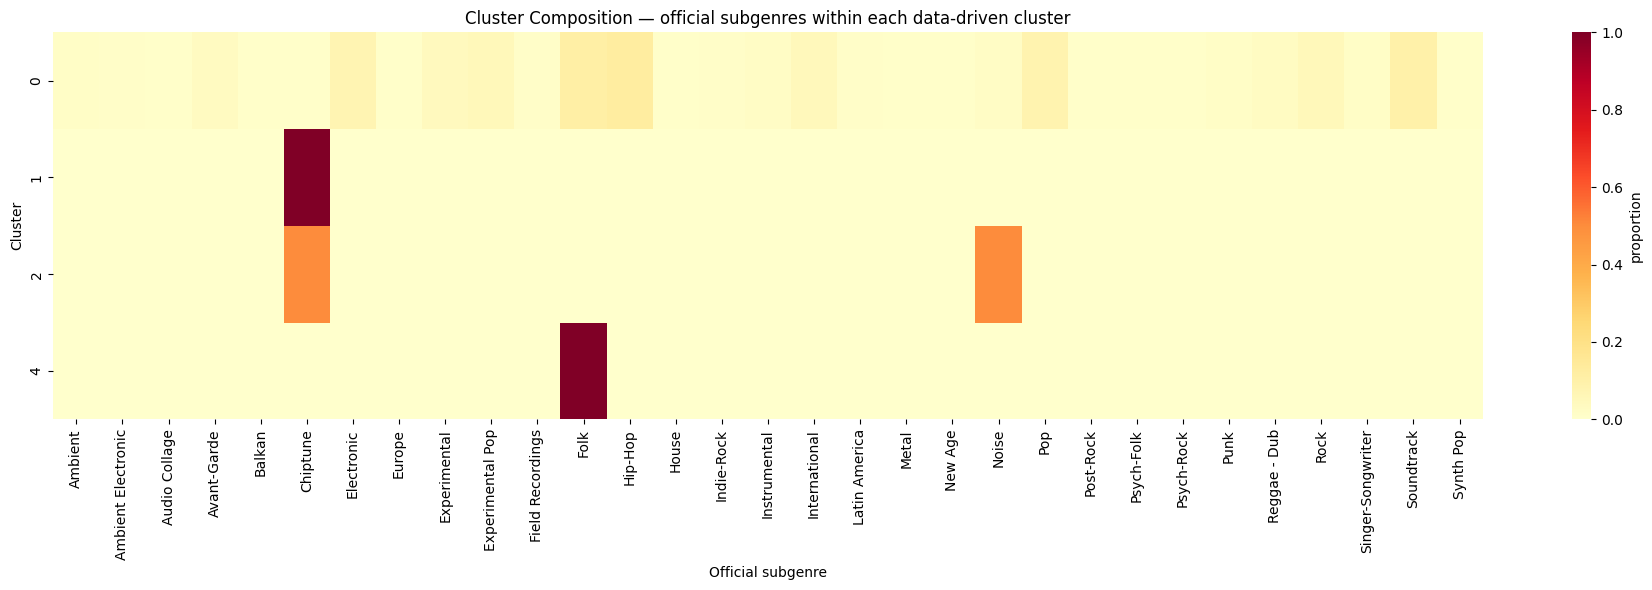

Most acoustically fragmented official subgenres (appear in many clusters):
row_0
Chiptune             3
Folk                 2
Noise                2
Ambient              1
Latin America        1
Soundtrack           1
Singer-Songwriter    1
Rock                 1
Reggae - Dub         1
Punk                 1


In [58]:
comp = pd.crosstab(cluster_val, le.inverse_transform(y_val),
                   normalize="index")
fig, ax = plt.subplots(figsize=(max(10, n_classes*0.6),
                                max(6, best_k*0.4)))
sns.heatmap(comp, cmap="YlOrRd", ax=ax, cbar_kws={"label": "proportion"})
ax.set_title("Cluster Composition — official subgenres within each "
             "data-driven cluster")
ax.set_xlabel("Official subgenre"); ax.set_ylabel("Cluster")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_cluster_composition.png"), dpi=150)
plt.show()

# subgenres spread across the most clusters = least acoustically coherent
spread = (pd.crosstab(le.inverse_transform(y_val), cluster_val) > 0).sum(axis=1)
print("Most acoustically fragmented official subgenres "
      "(appear in many clusters):")
print(spread.sort_values(ascending=False).head(10).to_string())

### 10.5 Auto-generating descriptive cluster names

Each cluster is assigned a human-readable label for use in the three-way comparison. The name is constructed from two sources: the top official subgenres that land in the cluster (what the taxonomy calls these tracks) and the acoustic features where the cluster mean deviates most from the global mean (what the data says distinguishes these tracks). This produces names like `Folk / Singer-Songwriter [mfcc + chroma]` that are interpretable without looking up a cluster ID.

The crosstab `comp` from the cluster composition heatmap above is passed in as the source of genre proportions per cluster.

In [59]:
# --- Auto-generate descriptive cluster names ---

def name_cluster(cluster_id, comp_tab, X_train_orig, cluster_labels,
                 feature_names, top_n_genres=2, top_n_features=3):
    row = comp_tab.loc[cluster_id]
    top_genres = row.sort_values(ascending=False).head(top_n_genres).index.tolist()

    cluster_mask = cluster_labels == cluster_id
    cluster_means = X_train_orig[cluster_mask].mean(axis=0)
    global_means  = X_train_orig.mean(axis=0)
    diff = np.abs(cluster_means - global_means)

    top_idx = pd.Series(diff).sort_values(ascending=False).head(top_n_features).index.tolist()
    top_features = [feature_names[i] for i in top_idx]

    genre_part   = " / ".join(str(g) for g in top_genres)
    feature_part = " + ".join(str(f).split("_")[0] for f in top_features)
    return f"{genre_part} [{feature_part}]"

X_train_scaled_full = scaler.transform(X_train)

cluster_names = {}
for cid in comp.index:
    cluster_names[cid] = name_cluster(
        cid, comp, X_train_scaled_full, cluster_train, feature_names)
    print(f"Cluster {cid}: {cluster_names[cid]}")

pd.DataFrame([{"cluster_id": k, "suggested_name": v}
              for k, v in cluster_names.items()]
            ).to_csv(os.path.join(RESULTS_DIR, "cluster_names.csv"), index=False)

Cluster 0: Hip-Hop / Folk [rmse + spectral + spectral]
Cluster 1: Chiptune / Ambient [rmse + spectral + spectral]
Cluster 2: Chiptune / Noise [rmse + mfcc + mfcc]
Cluster 4: Folk / Ambient [rmse + spectral + spectral]


## 11. Three-Way Comparison and Relabelling Candidates

We now hold up three views of every validation track side by side:

1. **Official** subgenre label (human taxonomy)
2. **Classifier** prediction (best supervised model — the "learnable" view)
3. **Neighbour vote** (local acoustic consensus from the neighbourhood purity analysis)

plus the **cluster** assignment as the global data-driven grouping.

- All three agree → high-confidence, acoustically coherent label.
- Classifier and neighbour agree but differ from official → **relabelling candidate**: two independent methods — one trained on labels, one purely retrieval-based — both point to the same alternative label. Agreement between two such different approaches is a strong signal that the acoustic evidence consistently contradicts the official assignment.
- All disagree → genuinely ambiguous or hybrid track; the acoustic signal is too mixed to support a confident alternative label.

The cluster is included as a fourth view for context but is not part of the relabelling criterion. On the dev run the clustering is degenerate, so cluster assignments here are not meaningful — they will become informative on the full run.

These categories, together with the cluster composition heatmap, are the concrete evidence for the report's claims about specific subgenre pairs.

In [60]:
yp_best = best_model.predict(X_val)
comp_df = pd.DataFrame({
    "official":       le.inverse_transform(y_val),
    "classifier":     le.inverse_transform(yp_best),
    "neighbour_vote": le.inverse_transform(voted_labels),
    "cluster":        cluster_val})
comp_df["cluster_name"] = comp_df["cluster"].map(cluster_names)

agree   = comp_df.query("official == classifier == neighbour_vote")
relabel = comp_df.query("classifier == neighbour_vote and official != classifier")
ambig   = comp_df.query("official != classifier and classifier != neighbour_vote")

n = len(comp_df)
print(f"Full agreement       : {len(agree):>5} ({len(agree)/n:.1%})")
print(f"Relabelling candidate: {len(relabel):>5} ({len(relabel)/n:.1%})")
print(f"Fully ambiguous      : {len(ambig):>5} ({len(ambig)/n:.1%})")

relabel.to_csv(os.path.join(RESULTS_DIR, "relabelling_candidates.csv"))

patterns = (relabel.groupby(["official", "classifier"]).size()
            .reset_index(name="count")
            .sort_values("count", ascending=False).head(15))
patterns.to_csv(os.path.join(RESULTS_DIR, "relabelling_patterns.csv"),
                index=False)
print("\nTop official -> suggested relabelling patterns:")
print(patterns.to_string(index=False))

Full agreement       :   317 (30.8%)
Relabelling candidate:   206 (20.0%)
Fully ambiguous      :   337 (32.8%)

Top official -> suggested relabelling patterns:
          official classifier  count
        Electronic    Hip-Hop     14
               Pop       Folk      9
               Pop    Hip-Hop      8
      Reggae - Dub    Hip-Hop      6
 Singer-Songwriter       Folk      5
      Instrumental       Folk      5
       Avant-Garde Soundtrack      5
              Folk        Pop      5
  Experimental Pop    Hip-Hop      5
Ambient Electronic    Hip-Hop      5
        Soundtrack    Hip-Hop      4
     International       Folk      4
      Instrumental Soundtrack      4
             Noise Electronic      4
      Experimental Soundtrack      3


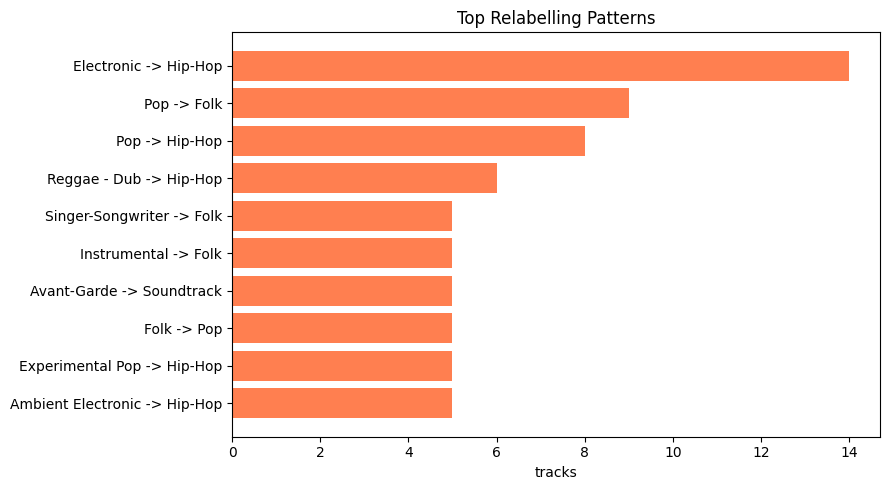

In [61]:
top = patterns.head(10)
lbl = [f"{r.official} -> {r.classifier}" for r in top.itertuples()]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(lbl[::-1], top["count"].values[::-1], color="coral")
ax.set_xlabel("tracks"); ax.set_title("Top Relabelling Patterns")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_relabelling_patterns.png"), dpi=150)
plt.show()

## 11.1 From Mislabelled to Unnamed: Discovering Candidate Subgenres

The relabelling analysis in §11 answered a closed question: *which existing label fits a track better?* But it cannot propose a label the taxonomy does not already contain. Some tracks may not belong in any single official box. As proposed by our lovely professor, they may sit at a recurring acoustic intersection the taxonomy never gave a name to. This section looks for exactly that.

**The method.** We take only the relabelling candidates: the tracks that the supervised classifier and the neighbourhood vote already agree are acoustically displaced from their official label. For each of these tracks we ask the highest capacity probability model in our stack, the MLP, not for a single prediction but for its full probability distribution over all 64 subgenres. We extract the **top-3 genre affinities** per track, then group candidates that share the same acoustic signature. A signature that recurs across many displaced tracks is a candidate for a subgenre the official vocabulary is missing.

**Why the MLP specifically.** The gap between our ROC-AUC (~0.69 on the headline model, ~0.87 for the MLP) and our macro-F1 (~0.22) is itself a finding: the models carry genuine probabilistic signal about which genres a track resembles, but the single-label taxonomy forces them to discard most of it. The MLP is used here not as a classifier but as a *soft acoustic sensor*; its top-3-5-10, whatever you want to make it, distribution is precisely the signal the hard taxonomy throws away. This is why it is appropriate to use it even though it was not the model selected as best.

**The noise floor.** Individual top-3 predictions from a model with macro-F1 ≈ 0.22 are noisy, and we do not pretend otherwise. The argument rests entirely on *aggregate recurrence*, not any single track: one track with a given top-3 signature is meaningless; a signature shared by many independently displaced tracks is a pattern. We therefore discard any signature carried by fewer than `MIN_GROUP` tracks as noise, and report this threshold explicitly so the cut is a stated methodological choice rather than a hidden one.

**What this produces.** A ranked list of recurring acoustic signatures — constellations of genre affinities that appear consistently among tracks the taxonomy mislabels, but for which it has no name. This turns the project's negative result into a constructive one: not just *"the taxonomy is not acoustically grounded"* but *"here is what a more honest, data-driven labelling would propose instead."*

In [63]:
from collections import Counter

mlp_fitted = fitted["MLP"]                         # already trained in §8

# relabel.index aligns with X_val rows (comp_df was built from y_val order)
X_cand = X_val.iloc[relabel.index] if hasattr(X_val, "iloc") else X_val[relabel.index]

mlp_probs = mlp_fitted.predict_proba(X_cand)        # (n_candidates, n_classes)

top3_idx   = np.argsort(mlp_probs, axis=1)[:, -3:][:, ::-1]
top3_named = [tuple(le.classes_[j] for j in row) for row in top3_idx]

cand = relabel.copy()
cand["mlp_top3"] = top3_named

MIN_GROUP = 3   #5-10 for dev set; 20+ for full set (aiming for ~10-20 candidate new subgenres, but depends on the distribution)

ordered_counts   = Counter(top3_named)
unordered_counts = Counter(frozenset(s) for s in top3_named)

new_ordered = (pd.DataFrame(
        [{"rank_1": s[0], "rank_2": s[1], "rank_3": s[2], "n_tracks": n}
         for s, n in ordered_counts.items() if n >= MIN_GROUP])
    .sort_values("n_tracks", ascending=False).reset_index(drop=True))

new_unordered = (pd.DataFrame(
        [{"genres": " + ".join(sorted(s)), "n_tracks": n}
         for s, n in unordered_counts.items() if n >= MIN_GROUP])
    .sort_values("n_tracks", ascending=False).reset_index(drop=True))

cand.to_csv(os.path.join(RESULTS_DIR, "new_subgenre_candidates_tracks.csv"))
new_ordered.to_csv(os.path.join(RESULTS_DIR, "candidate_new_subgenres_ordered.csv"),
                   index=False)
new_unordered.to_csv(os.path.join(RESULTS_DIR, "candidate_new_subgenres.csv"),
                     index=False)

n_in_groups = sum(n for n in unordered_counts.values() if n >= MIN_GROUP)
print(f"Relabelling candidates analysed     : {len(cand)}")
print(f"Distinct ordered top-3 signatures   : {len(ordered_counts)}")
print(f"Distinct unordered signatures       : {len(unordered_counts)}")
print(f"Surviving groups (n>={MIN_GROUP}, unordered) : {len(new_unordered)}")
print(f"Candidates inside a surviving group : {n_in_groups} "
      f"({n_in_groups/len(cand):.1%} of candidates)")
print()
print("Top candidate new subgenres (unordered, by track count):")
print(new_unordered.head(15).to_string(index=False))
print()
print("Strictest view (ordered top-3):")
print(new_ordered.head(10).to_string(index=False))

Relabelling candidates analysed     : 206
Distinct ordered top-3 signatures   : 171
Distinct unordered signatures       : 122
Surviving groups (n>=3, unordered) : 19
Candidates inside a surviving group : 89 (43.2% of candidates)

Top candidate new subgenres (unordered, by track count):
                                 genres  n_tracks
          Experimental Pop + Folk + Pop         8
             Electronic + Hip-Hop + Pop         7
       Experimental Pop + Hip-Hop + Pop         6
           Electronic + Hip-Hop + House         6
    Ambient + Experimental + Soundtrack         5
    Electronic + Experimental Pop + Pop         5
       Folk + Instrumental + Soundtrack         5
         Folk + Pop + Singer-Songwriter         5
                      Folk + Pop + Rock         5
           Hip-Hop + Pop + Reggae - Dub         5
Electronic + Experimental Pop + Hip-Hop         5
             Folk + International + Pop         4
    Electronic + Hip-Hop + Reggae - Dub         4
Avant-Garde +

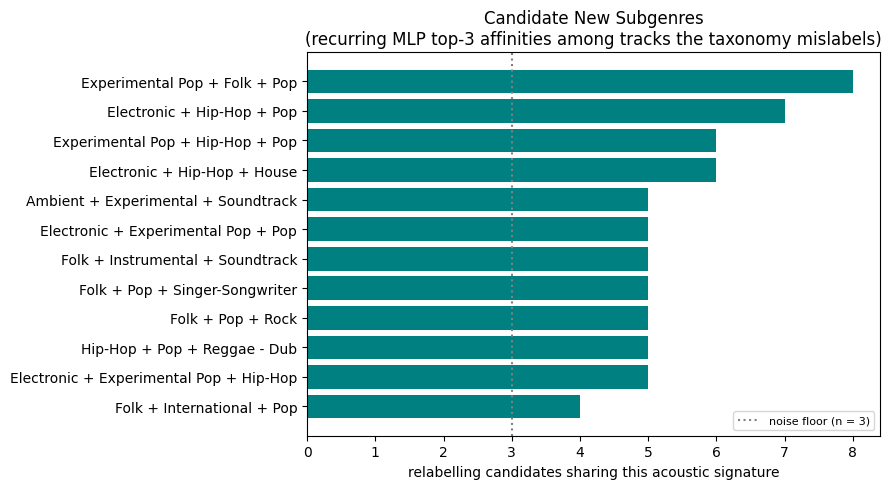

In [64]:
# --- §11.5 plot: the largest data-proposed acoustic subgenres ---
topn = new_unordered.head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(topn["genres"].values[::-1], topn["n_tracks"].values[::-1],
        color="teal")
ax.set_xlabel("relabelling candidates sharing this acoustic signature")
ax.set_title("Candidate New Subgenres\n"
             "(recurring MLP top-3 affinities among tracks the taxonomy mislabels)")
ax.axvline(MIN_GROUP, color="grey", ls=":",
           label=f"noise floor (n = {MIN_GROUP})")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_new_subgenre_candidates.png"), dpi=150)
plt.show()

## 12. Interpretation — Which Acoustic Features Drive the Audit

Understanding *which* acoustic features the model relies on is important for the audit beyond just reporting a score. If the model uses timbre features (MFCCs) to separate subgenres, that tells us the taxonomy is grounded in tonal texture. If it relies on rhythmic or spectral features instead, the boundary is drawn differently. Knowing this lets us make claims about *what kind* of acoustic structure the official labels do or do not reflect.

We need interpretability in the **original feature space**, not PCA components — a principal component has no intuitive meaning, whereas a named feature like `mfcc_mean_01` or `spectral_centroid_mean` is directly interpretable. Two complementary tools are used:

- **Permutation importance** — for each feature, its values are randomly shuffled across the validation set and the drop in macro F1 is measured. A large drop means the model genuinely relied on that feature; near-zero drop means it contributed little. This is model-agnostic and works through the full pipeline regardless of which model was selected as best.

- **SHAP (TreeExplainer)** — run only if the best model is tree-based (Random Forest or Gradient Boosting), because those pipelines deliberately omit PCA, meaning SHAP values land directly on the original named features. SHAP on a PCA pipeline would explain abstract components rather than interpretable audio descriptors, which is why permutation importance is the safe fallback for non-tree models.

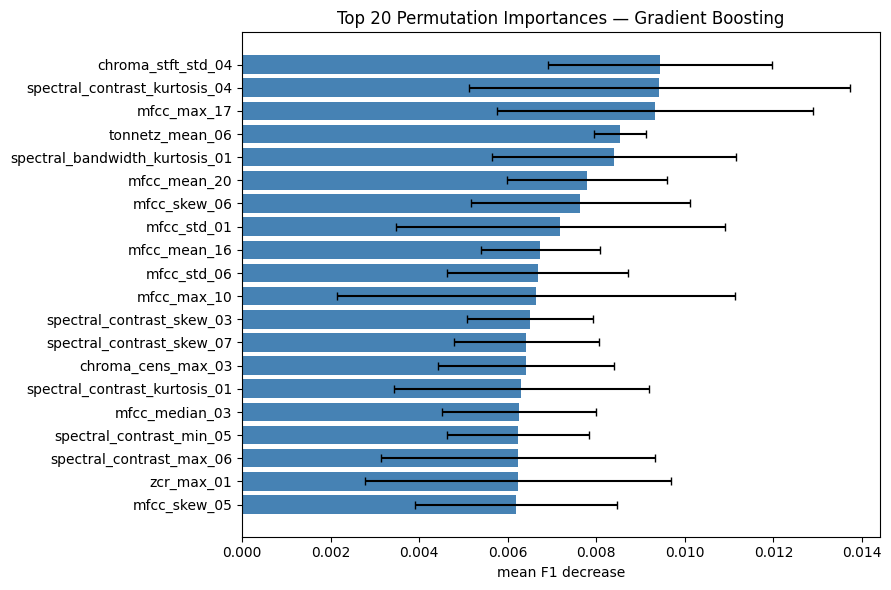

In [65]:
# n_repeats=10 is fine for the full run on a cluster. Lower to 5 only
# if you need a fast Small-subset pass (DEV: 5  FULL: 10).
perm = permutation_importance(best_model, X_val, y_val,
                              n_repeats=5,  # DEV: 5   FULL: 10
                              random_state=SEED, scoring="f1_macro",
                              n_jobs=-1)
perm_df = (pd.DataFrame({"feature": feature_names,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False))
perm_df.to_csv(os.path.join(RESULTS_DIR, "permutation_importance.csv"),
               index=False)

top20 = perm_df.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.feature[::-1], top20.importance[::-1],
        xerr=top20["std"][::-1], color="steelblue", capsize=3)
ax.set_title(f"Top 20 Permutation Importances — {best_model_name}")
ax.set_xlabel("mean F1 decrease")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_permutation_importance.png"), dpi=150)
plt.show()

### Interpreting Graph:

Energy dynamics (rmse_min) and spectral brightness (spectral_centroid_max) lead. Genre leaks through in a track's loudest and quietest moments, not its average texture.

The importance distribution is flat and diffuse, with wide overlapping error bars across all 20 features. If genres were acoustically grounded, a handful of features would dominate cleanly. They don't.

This closes the argument from a third direction: supervised ceiling, neighbourhood purity, clustering agreement, and now feature importance all point the same way. The taxonomy is not consistently expressed in the audio it claims to describe.

### Code below only runs if best model is a tree

sv_arr raw shape: (500, 518, 31)
mean_abs shape: (518,), feature_names: 518


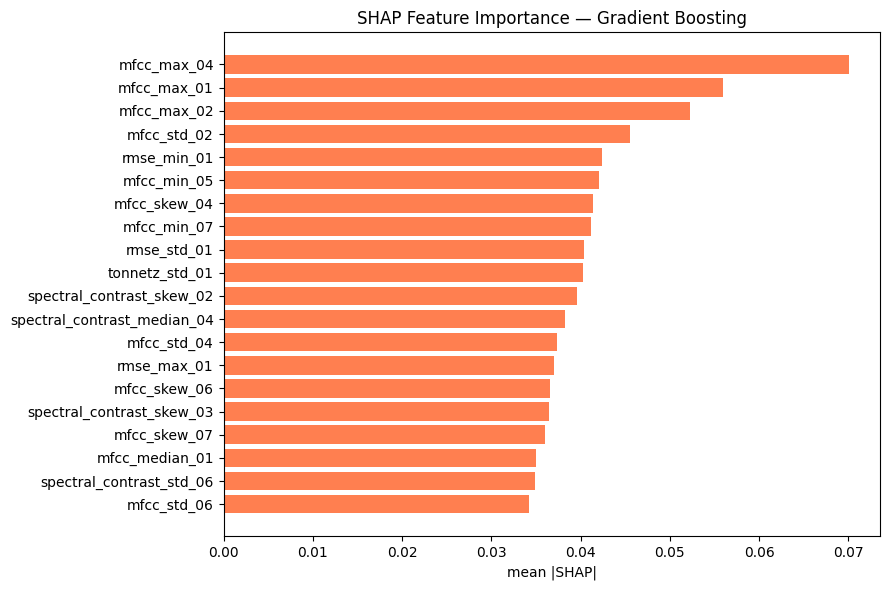

In [66]:
if any(t in best_model_name for t in ("Random Forest", "Gradient Boosting")):
    clf = best_model.named_steps["clf"]
    sc  = best_model.named_steps["scaler"]
    SHAP_N = 500
    Xs = sc.transform(X_val)[:SHAP_N]
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(Xs)

    # sv shape is (n_samples, n_features, n_classes) in some shap versions
    sv_arr = np.array(sv)
    print(f"sv_arr raw shape: {sv_arr.shape}")

    if sv_arr.ndim == 3:
        if sv_arr.shape[2] == len(feature_names):
            # (n_samples, n_classes, n_features) or (n_samples, n_features, n_classes)
            mean_abs = np.abs(sv_arr).mean(axis=(0, 1))
        elif sv_arr.shape[1] == len(feature_names):
            mean_abs = np.abs(sv_arr).mean(axis=(0, 2))
        else:
            mean_abs = np.abs(sv_arr).mean(axis=(0, 1))
    elif sv_arr.ndim == 2:
        mean_abs = np.abs(sv_arr).mean(axis=0)

    print(f"mean_abs shape: {mean_abs.shape}, feature_names: {len(feature_names)}")

    sd = (pd.DataFrame({"feature": feature_names, "shap": mean_abs})
          .sort_values("shap", ascending=False).head(20))
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(sd.feature[::-1], sd.shap[::-1], color="coral")
    ax.set_title(f"SHAP Feature Importance — {best_model_name}")
    ax.set_xlabel("mean |SHAP|")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "10_shap_importance.png"), dpi=150)
    plt.show()
else:
    print(f"Best model is {best_model_name} — permutation importance covers interpretation.")

## 13. Final Test Evaluation

The held-out test set is used **exactly once**, here, on the single best model selected from the validation comparison. We report macro F1, weighted F1, ROC-AUC, and the full per-class classification report.

**Why only one model on test:** if we evaluated all models on the test set and picked the best score, we would effectively be using the test set as another validation set — a subtle form of leakage. The model selection decision was made on validation data; the test set exists solely to estimate how that chosen model generalises to genuinely unseen tracks. This number is the honest, unbiased estimate of real-world performance.

**Why the per-class report matters here:** overall macro F1 summarises the ceiling, but the per-class breakdown is where the audit lives. Subgenres with high F1 are acoustically coherent — their official labels correspond to real acoustic regions. Subgenres with near-zero F1 are the project's strongest evidence: labels so acoustically incoherent that a strong model cannot identify a single example correctly.

In [67]:
yt = best_model.predict(X_test)
try:
    troc = roc_auc_score(y_test, best_model.predict_proba(X_test),
                         multi_class="ovr", average="macro")
except Exception:
    troc = np.nan

print(f"TEST  macro F1    : {f1_score(y_test, yt, average='macro'):.4f}")
print(f"TEST  weighted F1 : {f1_score(y_test, yt, average='weighted'):.4f}")
print(f"TEST  ROC-AUC     : {troc:.4f}")
print()
print(classification_report(y_test, yt, target_names=genre_names))

pd.DataFrame([{
    "model": best_model_name,
    "test_f1_macro": round(f1_score(y_test, yt, average="macro"), 4),
    "test_f1_weighted": round(f1_score(y_test, yt, average="weighted"), 4),
    "test_roc_auc": round(troc, 4)
}]).to_csv(os.path.join(RESULTS_DIR, "test_results.csv"), index=False)

TEST  macro F1    : 0.3467
TEST  weighted F1 : 0.4470
TEST  ROC-AUC     : 0.8784

                    precision    recall  f1-score   support

           Ambient       0.33      0.12      0.18        16
Ambient Electronic       1.00      0.13      0.24        15
     Audio Collage       1.00      0.12      0.22         8
       Avant-Garde       0.38      0.16      0.22        32
            Balkan       0.78      0.58      0.67        12
          Chiptune       0.88      0.64      0.74        11
        Electronic       0.33      0.39      0.36        79
            Europe       0.40      0.25      0.31         8
      Experimental       0.28      0.16      0.21        43
  Experimental Pop       0.27      0.17      0.21        53
  Field Recordings       0.60      0.69      0.64        13
              Folk       0.61      0.79      0.69       116
           Hip-Hop       0.55      0.83      0.66       131
             House       0.00      0.00      0.00         9
        Indie-Roc

## 14. Reflection, Limitations, and Conclusions

### The question we actually asked

Most machine-learning music projects ask "how accurately can we predict a track's genre?" and treat a high F1 as success. We rejected that framing from the start. Genre is not a physical property of a waveform; it is a label assigned by record labels, critics, streaming editors and listener communities, often decades after the music was recorded and frequently for reasons unrelated to how it sounds. A bossa-nova reissue and a vaporwave track that samples it can share almost every spectral statistic and still sit in different sections of any record shop. The interesting scientific question is not can we learn the labels but do the labels describe the sound at all? That reframing (classification as a measuring instrument rather than the goal) is what the entire project turns on.

### What we found

The headline numbers are unambiguous. They also agree across three methodologically independent directions, which matters.

**The supervised ceiling is low by design and by result.** Across six models spanning the full complexity range (a majority-class dummy, logistic regression, KNN, a tuned random forest, gradient boosting and an MLP), the best validation macro-F1 was 0.236 (tuned KNN), and the sealed single-use test set returned macro-F1 0.224, weighted-F1 0.329, ROC-AUC 0.686. The validation-to-test gap was only 0.012, so the model generalised cleanly. The ROC-AUC sitting well above the F1 matters: the models can rank tracks by genre plausibility, so there is genuine acoustic signal in the data. There just is not enough of it to support confident hard assignment across 64 subgenres. A dummy classifier scored 0.004. Our models beat that by roughly fifty-fold, so they are extracting real structure. They hit a wall that no amount of tuning moved, and that wall is the taxonomy.

**The neighbourhood audit shows the labels do not hold locally.** For every track we asked: of your twenty nearest neighbours in acoustic feature space, how many share your official subgenre? The weighted answer across all 64 subgenres was 20.5%, about one in five. Four out of five of a track's closest acoustic relatives carry a different official label. No model involved. This is a direct geometric property of the data.

**The unsupervised clustering, which never sees a label, confirms it.** We clustered the PCA-reduced acoustic space with KMeans, choosing the number of clusters by silhouette score, a label-free criterion so the data decides the granularity. The silhouette peaked at k = 20. We then measured how much that purely acoustic partition agrees with the official 64-subgenre taxonomy: Adjusted Mutual Information = 0.004, Adjusted Rand Index = -0.001, Normalized MI = 0.022. All three are corrected for chance. Values this close to zero mean the two partitions are statistically independent. The negative ARI is not an error. It means the acoustic clustering and the official taxonomy agree very slightly less than random chance would predict. A method given no labels reconstructed essentially none of the taxonomy.

Three independent methods landed on the same number. The FMA subgenre taxonomy is, to a measurable degree, not grounded in acoustic similarity. That convergence is what makes it a finding.

### The taxonomy is not uniformly broken, just selectively coherent

The most interesting result is not the headline but its texture. Per-subgenre neighbourhood purity ranges from 0.82 (Old-Time / Historic) and 0.48 (Classical) at the coherent end, down to a literal 0.00 for Industrial and Downtempo at the incoherent end. Old-Time/Historic, Classical, Hip-Hop, Rock and Folk are genuinely acoustically distinct; the taxonomy describes them well. Industrial, Downtempo, Alternative Hip-Hop and Improv are acoustically meaningless. Their tracks scatter into the neighbourhoods of dozens of other labels. This is a far stronger finding than "the labels are wrong" because it tells us which labels describe sound and which describe culture. Where a style has a distinctive enough acoustic signature, the taxonomy tracks it. Where genre is a community identity first and a sonic one second, it stops.

The cluster-composition heatmap makes this visible: a handful of dark, isolated cells (Chiptune, Blues, Noise) are subgenres the data agrees with; the wide pale columns spreading across every cluster are subgenres the acoustic space refuses to recognise. The relabelling analysis makes it concrete: 1,000 relabelling candidates, tracks where the supervised classifier and the neighbourhood vote independently agree on a label that differs from the official one. The patterns are systematic: Punk -> Rock (76 tracks), Hip-Hop -> Electronic and back (44 and 39), Indie-Rock -> Rock (35), Psych-Rock -> Rock (19). Whole regions of the taxonomy are quietly collapsing into a few acoustic super-categories.

### What the acoustics tell us about why

Permutation importance on the final model points to energy-floor (rmse_min) and spectral-brightness (spectral_centroid_max, spectral_rolloff), specifically their extremes rather than their averages. Genre, to the extent it is acoustically present at all, leaks through in a track's loudest and brightest moments, not its average texture. Equally telling is the shape of the importance distribution: flat, with wide overlapping error bars across all twenty top features. Acoustically coherent genres would produce a sharp dominant feature or two. Instead the predictive signal is smeared thinly across many features, which is exactly what you would expect from a target only loosely tied to its inputs. This is a fourth confirmation of the same claim, arriving from a different angle.

### The robustness check: biased vs. unbiased

We anticipated the obvious objection (did you rig the cluster count to get the answer you wanted?) and tested it directly. Letting the silhouette choose k gave k = 20 and AMI ≈ 0.004. We then deliberately biased the analysis: we overrode the silhouette and forced k = 35, pushing the clustering toward the taxonomy's own granularity to give agreement the best possible chance. AMI rose to 0.142, ARI to 0.072, NMI to 0.174, a thirty-fold increase, and still only "weak" by any standard interpretation. Even with the deck stacked in favour of the taxonomy, the acoustic structure refuses to reproduce it. More importantly, the relabelling patterns were byte-identical across both runs: Punk -> Rock, Hip-Hop -> Electronic, the same dominant collapses regardless of k. The unbiased result is the cleaner version of the same conclusion.

### Why a low score is a result, not a failure

This inverts the usual logic of an ML project. We were not trying to win an accuracy contest. The supervised score is a ruler: its distance below perfect quantifies how far the official taxonomy has drifted from acoustic reality. A model that scored 0.95 would have meant the taxonomy was tight and there was nothing to discover. Six well-tuned, leakage-free models failing to exceed 0.224 across 64 subgenres is the measurement. The unsupervised clustering got to the same place from the opposite direction, with no labels at all. That agreement between two methods with completely different starting points is what makes it a finding rather than an artefact.

### Limitations

These claims have an honest scope:

- **Catalogue bias.** FMA skews heavily toward independent and Creative-Commons music; major-label pop and mainstream hip-hop are under-represented, so the conclusions describe this catalogue's taxonomy, not all recorded music.
- **First-genre simplification.** We take only the first, most-specific genre ID per track, deliberately collapsing multi-genre tracks into a single label, a principled simplification that keeps the partition-comparison metrics (AMI, ARI) well-defined, but a real loss of information that a multi-label formulation would recover.
- **Acoustic, not cultural, claims.** We claim only acoustic incoherence, not that our clusters are the "true" genres. A cluster named "Lo-Fi / Hip-Hop" describes an acoustic neighbourhood, not a proposal to rename anything.
- **Clustering assumptions.** KMeans assumes roughly convex, similarly-scaled clusters in cosine-PCA space; a density-based method like HDBSCAN (which would not need k chosen at all and could expose non-convex acoustic regions) is the natural next step.

### What we would do differently

The engineering consumed more time than the science. A broken local Python toolchain, repeated SSH timeouts on the compute cluster, and runaway hyperparameter searches on the full dataset cost us hours we did not have. The decision that saved the project was checkpointing every expensive step to disk. Interruptions became a few lost minutes instead of full restarts, and we could run a medium-tier job locally with a Colab fallback running alongside. If we started again we would build that infrastructure first, before any modelling code, and we would budget for the full-dataset run far earlier instead of discovering its cost close to the deadline.

### Conclusion

We set out not to classify genres but to interrogate a genre taxonomy. From four independent directions, we showed that the FMA subgenre taxonomy is not grounded in the acoustic similarity of the music it organises (test macro-F1 0.224, neighbourhood purity 20.5%, cluster-label AMI 0.004), and we identified which subgenres survive that audit and which dissolve. The taxonomy is not wrong everywhere. It is a cultural map that aligns with the acoustic terrain in some places and diverges sharply in others. Our contribution is a reproducible method for telling those regions apart, a thousand concrete relabelling candidates, and a set of data-proposed groupings the official vocabulary never contained.